# <center> Исследование данных HR-агентства

## Постановка задачи

HR-агентство изучает тренды на рынке труда в IT. 
Компания хочет провести исследование на основе данных о зарплатах в сфере Data Science за 2020–2022 годы и получить некоторые выводы:

- Выяснить, какие факторы влияют на зарплату специалиста Data Scientist.
- Наблюдается ли ежегодный рост зарплат у специалистов Data Scientist?
- Как соотносятся зарплаты Data Scientist и Data Engineer в 2022 году?
- Как соотносятся зарплаты специалистов Data Scientist в компаниях различных размеров?
- Есть ли связь между наличием должностей Data Scientist и Data Engineer и размером компании?

На каждый вопрос необходимо ответить с уровнем значимости $\alpha=0.05$.

Ответить на эти вопросы нам помогут данные о зарплатах в сфере Data Science за 2020–2022 годы.

Данные содержат следующие столбцы:
*   *work_year* — Год, в котором была выплачена зарплата;
*   *experience_level* — Опыт работы на этой должности в течение года: EN — Entry-level/Junior; MI — Mid-level/Intermediate; SE — Senior-level/Expert; EX — Executive-level/Director;
*   *employment_type* — Тип трудоустройства для этой роли: PT — неполный рабочий день; FT — полный рабочий день; CT — контракт; FL — фриланс;
*   *job_title* — Роль, в которой соискатель работал в течение года;
*   *salary* — Общая выплаченная валовая сумма заработной платы;
*   *salary_currency* — Валюта выплачиваемой заработной платы в виде кода валюты ISO 4217;
*   *salary_in_usd* — Зарплата в долларах США;
*   *employee_residence* — Основная страна проживания сотрудника в течение рабочего года в виде кода страны ISO 3166;
*   *remote_ratio* — Общий объём работы, выполняемой удалённо: 0 — удалённой работы нет (менее 20 %); 50 — частично удалённая работа; 100 — полностью удалённая работа (более 80 %);
*   *company_location* — Страна главного офиса работодателя или филиала по контракту в виде кода страны ISO 3166;
*   *company_size* — Среднее количество людей, работавших в компании в течение года: S — менее 50 сотрудников (небольшая компания); M — от 50 до 250 сотрудников (средняя компания); L — более 250 сотрудников (крупная компания).

Оригинальный датасет: “Data Science Job Salaries” (kaggle.com)

## Загрузка данных

In [59]:
# загружаем необходимые библиотеки
import numpy as np
import pandas as pd
from sklearn import datasets

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

from scipy import stats
from scipy.stats import shapiro
import statsmodels.api as sm
from statsmodels import stats as sms

# делаем визуальную настройку графиков
sns.set_theme("notebook") 
sns.set_palette("Set2") 

In [60]:
# загружаем датасет
df_salaries = pd.read_csv('data/ds_salaries.csv')
df_salaries.head()

,Unnamed: 0,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,0,2020,MI,FT,Data Scientist,70000,EUR,79833,DE,0,DE,L
1,1,2020,SE,FT,Machine Learning Scientist,260000,USD,260000,JP,0,JP,S
2,2,2020,SE,FT,Big Data Engineer,85000,GBP,109024,GB,50,GB,M
3,3,2020,MI,FT,Product Data Analyst,20000,USD,20000,HN,0,HN,S
4,4,2020,SE,FT,Machine Learning Engineer,150000,USD,150000,US,50,US,L


In [61]:
# задаём уровень значимости
alpha = 0.05
print('Уровень значимости alpha = {:.2f}'.format(alpha))

Уровень значимости alpha = 0.05


## Описательный анализ данных

In [62]:
print("Data Shape:", df_salaries.shape)

Data Shape: (607, 12)


In [63]:
df_salaries.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 607 entries, 0 to 606
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Unnamed: 0          607 non-null    int64 
 1   work_year           607 non-null    int64 
 2   experience_level    607 non-null    object
 3   employment_type     607 non-null    object
 4   job_title           607 non-null    object
 5   salary              607 non-null    int64 
 6   salary_currency     607 non-null    object
 7   salary_in_usd       607 non-null    int64 
 8   employee_residence  607 non-null    object
 9   remote_ratio        607 non-null    int64 
 10  company_location    607 non-null    object
 11  company_size        607 non-null    object
dtypes: int64(5), object(7)
memory usage: 57.0+ KB


Пропусков в данных нет, количество строк 607, столбцов 12.

Числовые признаки : salary, salary_in_usd

Категориальные признаки : experience_level, employment_type, job_title, salary_currency, employee_residence, company_location, work_year, remote_ratio and company_size.

Типы данных корректны для числовых (int64) и категориальных (object) признаков.

In [64]:
df_salaries.drop(columns="Unnamed: 0", axis=1, inplace=True)
print('Размер таблицы после удаления неинформативного признака: {}'.format(df_salaries.shape))

Размер таблицы после удаления неинформативного признака: (607, 11)


Проверим данные на наличие полных дубликатов:

In [65]:
print('Количество дубликатов: {}'.format(df_salaries[df_salaries.duplicated()].shape[0]))

# Удаляем дубликаты:
df_salaries = df_salaries.drop_duplicates()
print('Размер таблицы после удаления дубликатов: {}'.format(df_salaries.shape))

Количество дубликатов: 42
Размер таблицы после удаления дубликатов: (565, 11)


Проверим признаки на возможность отнесения к категориальным:

In [66]:
df_salaries["remote_ratio"].value_counts()

remote_ratio
100    346
0      121
50      98
Name: count, dtype: int64

In [67]:
df_salaries["work_year"].value_counts()

work_year
2022    278
2021    215
2020     72
Name: count, dtype: int64

In [68]:
# Определяем столбцы согласно типу признака на категориальные и числовые
num_features = ["salary", "salary_in_usd"]
cat_features = ["remote_ratio", "work_year", "experience_level", "employment_type", "job_title", "salary_currency", "company_size"]

In [69]:
# Выведем описательную статистику для числовых признаков
print("Data describe:")
display(df_salaries.drop(columns=cat_features, axis=1).describe().T.style)

Data describe:


,count,mean,std,min,25%,50%,75%,max
salary,565.000000,338115.985841,1599878.789228,4000.000000,67000.000000,110925.000000,165000.000000,30400000.000000
salary_in_usd,565.000000,110610.343363,72280.702792,2859.000000,60757.000000,100000.000000,150000.000000,600000.000000


In [70]:
# Создаем функцию для отнесения столбцов к типу категориальных
def convert_cat(df, cat_features= cat_features):
    for feature in cat_features:
        if feature in df.columns:
            df[feature] = df[feature].astype("category")
        else:
            pass

convert_cat(df=df_salaries)

# Выведем описательную статистику для категоральных признаков
print("Data describe:")
display(df_salaries.drop(columns=num_features, axis=1).describe().T.style)

Data describe:


,count,unique,top,freq
work_year,565,3,2022,278
experience_level,565,4,SE,243
employment_type,565,4,FT,546
job_title,565,50,Data Scientist,130
salary_currency,565,17,USD,359
employee_residence,565,57,US,295
remote_ratio,565,3,100,346
company_location,565,50,US,318
company_size,565,3,M,290


*Выводы по описательным статистикам числовых признаков:*
*   salary: Распределение смещено вправо, очень большое стандартное отклонение (1,599,879), что означает большой разброс в значениях от среднего арифметического (338,116). Минимальное значение 4000, а макисмальное 30,400,000, очень большая вероятность выбросов за счет разных валют. Признак не достаточно информативен по сравенению с salary_in_usd, поэтому можно избавиться от него. Вместе с ним можно избавиться и от столбца salary_currency.
* salary_in_usd: Распределение все также смещено вправо, разброс присутствует и также зависит от роли, страны и опыта специалиста. 
Среднее значение 110,610, стандартное отклонение 72,281. Разброс от минимума в 2,859 до максимального значения в 600,000.

*Выводы по описательным статистикам категориальных прзнаков:*
* work_year (3 значения: 2020–2022): Данные в большей степени отражают картину за 2022 год, почти 50% записей относится к нему (278 из 565).
* experience_level (4 уровня): Уровень SE (Senior) преобладает в датасете (243 из 565).
* employment_type (4 типа): FT (Full-time) график работы - 97% от всего датасета. Признак является непоказательным для исследования.
* job_title (50 уникальных): Разнообразные роли, преобладает Data Scientist (130 из 565).
* salary_currency (17 типов): Самая популярная валюта USD (359 из 565). Данный признак было решено убрать вместе с salary.
* employee_residence (57 стран): Большая часть опрошеных (52%) работают в US (295 из 565).
* remote_ratio (3 уровня: 0–50–100): Видно, что большинство предпочитает полностью удаленный график (346 из 565).
* company_location (50 стран): Все также наибольшая доля работодателей относится к рынку US, что соответствует и предыдущим характеристикам. 
* company_size (3 уровня: S–M–L): Средний размер компании (M (Medium)) наиболее популярен (290 из 565).

Удаляем неинформативные признаки salary и salary_currency и employment_type

In [71]:
df_salaries = df_salaries.drop(['salary', 'salary_currency','employment_type'], axis=1)
print('Размер таблицы после удаления неинформативных признаков: {}'.format(df_salaries.shape))

Размер таблицы после удаления неинформативных признаков: (565, 8)


Выведем 10 наиболее популярных профессий из датасета

In [72]:
df_salaries["job_title"].value_counts().head(10)

job_title
Data Scientist                130
Data Engineer                 121
Data Analyst                   82
Machine Learning Engineer      39
Research Scientist             16
Data Science Manager           12
Data Architect                 11
Big Data Engineer               8
Machine Learning Scientist      8
Data Analytics Manager          7
Name: count, dtype: int64

Так как для HR-агентства важно посмотреть на наиболее популярные профессии (Data Scientist , Data Engineer), то мы создадим вспомогательный столбец, чтобы увеличить рассматриваемую выборку для данных специальностей:

In [ ]:
from collections import Counter
# Формируем список всех специальностей.
lst_all_job_titles = list(Counter(df_salaries['job_title']))
# Отбираем с помощью цикла в соответствуеющие списки все наименования содержащие в себе указанные текстовые маркеры.
lst_ds, lst_de = [], []
for x in lst_all_job_titles:
    if 'Data Scien' in x:
        lst_ds.append(x)
    if 'Data Engin' in x:
        lst_de.append(x)

# Создадим два новых вспомогательных категориальных признака.
df_salaries['is_ds'] = df_salaries['job_title'].apply(lambda x: 1 if x in lst_ds else 0)
df_salaries['is_de'] = df_salaries['job_title'].apply(lambda x: 1 if x in lst_de else 0)
# Объединим их значения для удобства в новом признаке.
df_salaries['is_ds_or_de'] = df_salaries['is_ds'] + df_salaries['is_de']
df_salaries["is_ds_or_de"].value_counts()

is_ds_or_de
1    326
0    239
Name: count, dtype: int64

На основе признаков employee_residence и company_location можно создать вспомагательный признак, сообщающий о совпадении страны проживания специалиста и страны расположения работдателя.

In [74]:
# Создадим вспомогательный географический признак.
df_salaries['geo_proximity'] = df_salaries['employee_residence'] == df_salaries['company_location']
df_salaries['employee_residence'] = df_salaries['employee_residence'].astype('category')
df_salaries['company_location'] = df_salaries['company_location'].astype('category')
df_salaries['geo_proximity'] = df_salaries['geo_proximity'].astype('category')

Для подтверждения наблюдений по признакам выше построим графики распределения внутри каждого признака:

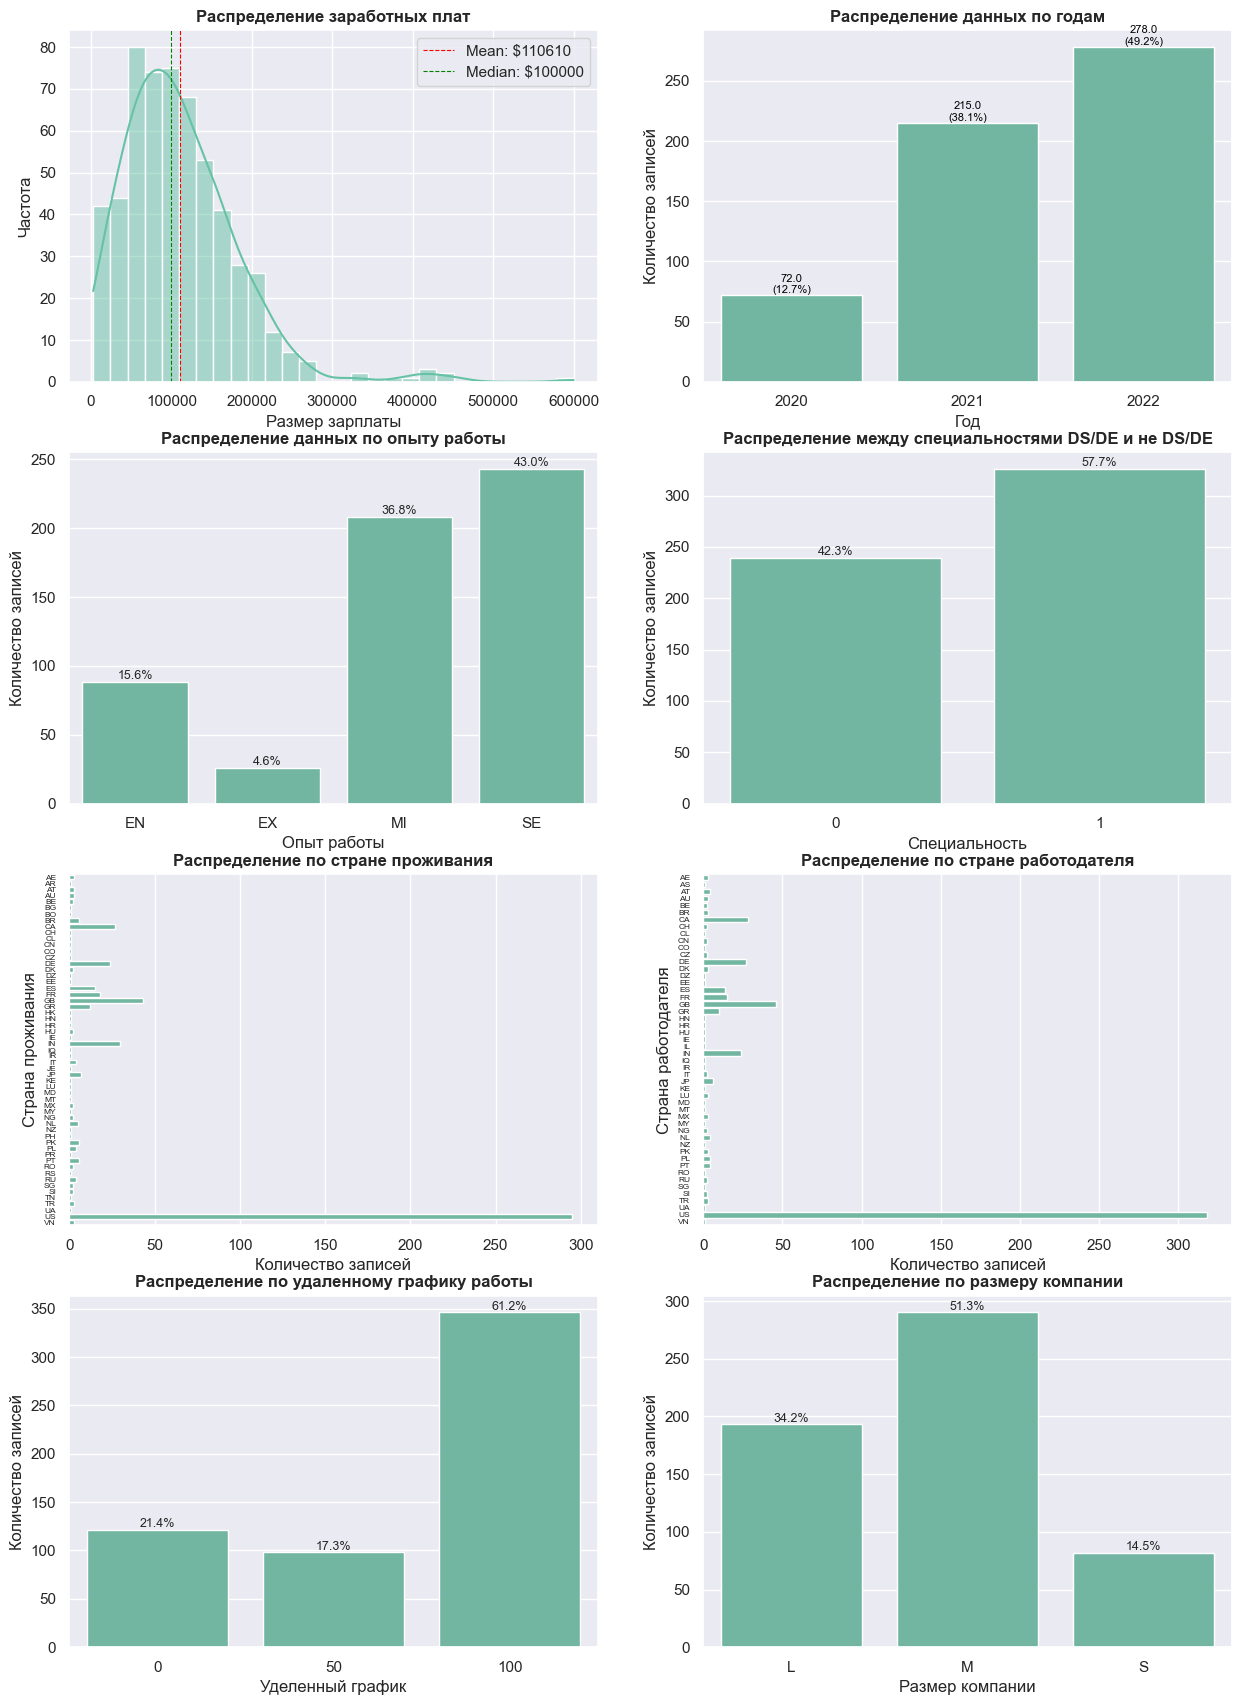

In [75]:
# Задаем параметры поля для графиков.
fig, axes = plt.subplots(4, 2, figsize=(15, 21))

# Распределение частот заработных плат.
axes[0][0] = sns.histplot(df_salaries['salary_in_usd'], kde=True, ax=axes[0][0])
axes[0][0].set(xlabel='Размер зарплаты', ylabel='Частота')
axes[0][0].set_title('Распределение заработных плат', weight='bold')
axes[0][0].axvline(df_salaries['salary_in_usd'].mean(), color='red', linestyle='--', linewidth=0.8, 
                   label=f'Mean: ${df_salaries["salary_in_usd"].mean():.0f}')
axes[0][0].axvline(df_salaries['salary_in_usd'].median(), color='green', linestyle='--', linewidth=0.8, 
                   label=f'Median: ${df_salaries["salary_in_usd"].median():.0f}')
axes[0][0].legend()

# Гистограмма распределения данных по годам.
axes[0][1] = sns.countplot(x=df_salaries['work_year'], ax=axes[0][1])
axes[0][1].set(xlabel='Год', ylabel='Количество записей')
axes[0][1].set_title('Распределение данных по годам', weight='bold')

total = len(df_salaries['work_year'])
for p in axes[0][1].patches:
    height = p.get_height()
    percentage = f'{100 * height / total:.1f}%'
    axes[0][1].annotate(f'{height}\n({percentage})', 
                       (p.get_x() + p.get_width() / 2., height + 0.01),
                       ha='center', va='bottom', fontsize=8, color='black')

# Гистограмма распределения данных по опыту работы.
axes[1][0] = sns.countplot(x=df_salaries['experience_level'], ax=axes[1][0])
axes[1][0].set(xlabel='Опыт работы', ylabel='Количество записей')
axes[1][0].set_title('Распределение данных по опыту работы', weight='bold')

total_exp = len(df_salaries['experience_level'])
for p in axes[1][0].patches:
    percentage = f'{100 * p.get_height() / total_exp:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height() + 0.01
    axes[1][0].annotate(percentage, (x, y), ha='center', va='bottom', fontsize=9)

# Гистограмма распределения данных по специальности.
axes[1][1] = sns.countplot(x=df_salaries['is_ds_or_de'], ax=axes[1][1])
axes[1][1].set(xlabel='Специальность', ylabel='Количество записей')
axes[1][1].set_title('Распределение между специальностями DS/DE и не DS/DE', weight='bold')

total_ds = len(df_salaries['is_ds_or_de'])
for p in axes[1][1].patches:
    percentage = f'{100 * p.get_height() / total_ds:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height() + 0.01
    axes[1][1].annotate(percentage, (x, y), ha='center', va='bottom', fontsize=9)

#Гистограмма распределения данных по стране проживания.
axes[2][0] = sns.barplot(x=df_salaries['employee_residence'].value_counts().values,
                         y=df_salaries['employee_residence'].value_counts().index,
                         ax=axes[2][0],
                         orient='h')
axes[2][0].set(xlabel='Количество записей', ylabel='Страна проживания')
axes[2][0].set_title('Распределение по стране проживания', weight='bold')
axes[2][0].tick_params(axis='y', labelsize=6)

#Гистограмма распределения данных по стране работодателя.
axes[2][1] = sns.barplot(x=df_salaries['company_location'].value_counts().values,
                         y=df_salaries['company_location'].value_counts().index,
                         ax=axes[2][1],
                         orient='h')
axes[2][1].set(xlabel='Количество записей', ylabel='Страна работодателя')
axes[2][1].set_title('Распределение по стране работодателя', weight='bold')
axes[2][1].tick_params(axis='y', labelsize=6)

#Гистограмма распределения данных по удаленному графику работы.
axes[3][0] = sns.countplot(x=df_salaries['remote_ratio'], ax=axes[3][0])
axes[3][0].set(xlabel='Уделенный график', ylabel='Количество записей')
axes[3][0].set_title('Распределение по удаленному графику работы', weight='bold')

total_ds = len(df_salaries['remote_ratio'])
for p in axes[3][0].patches:
    percentage = f'{100 * p.get_height() / total_ds:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height() + 0.01
    axes[3][0].annotate(percentage, (x, y), ha='center', va='bottom', fontsize=9)

#Гистограмма распределения данных по размеру компании.
axes[3][1] = sns.countplot(x=df_salaries['company_size'], ax=axes[3][1])
axes[3][1].set(xlabel='Размер компании', ylabel='Количество записей')
axes[3][1].set_title('Распределение по размеру компании', weight='bold')

total_ds = len(df_salaries['company_size'])
for p in axes[3][1].patches:
    percentage = f'{100 * p.get_height() / total_ds:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height() + 0.01
    axes[3][1].annotate(percentage, (x, y), ha='center', va='bottom', fontsize=9)
    
plt.show()

## Разведывательный анализ данных

### Распределение заработных плат в зависимости от уровня квалификации

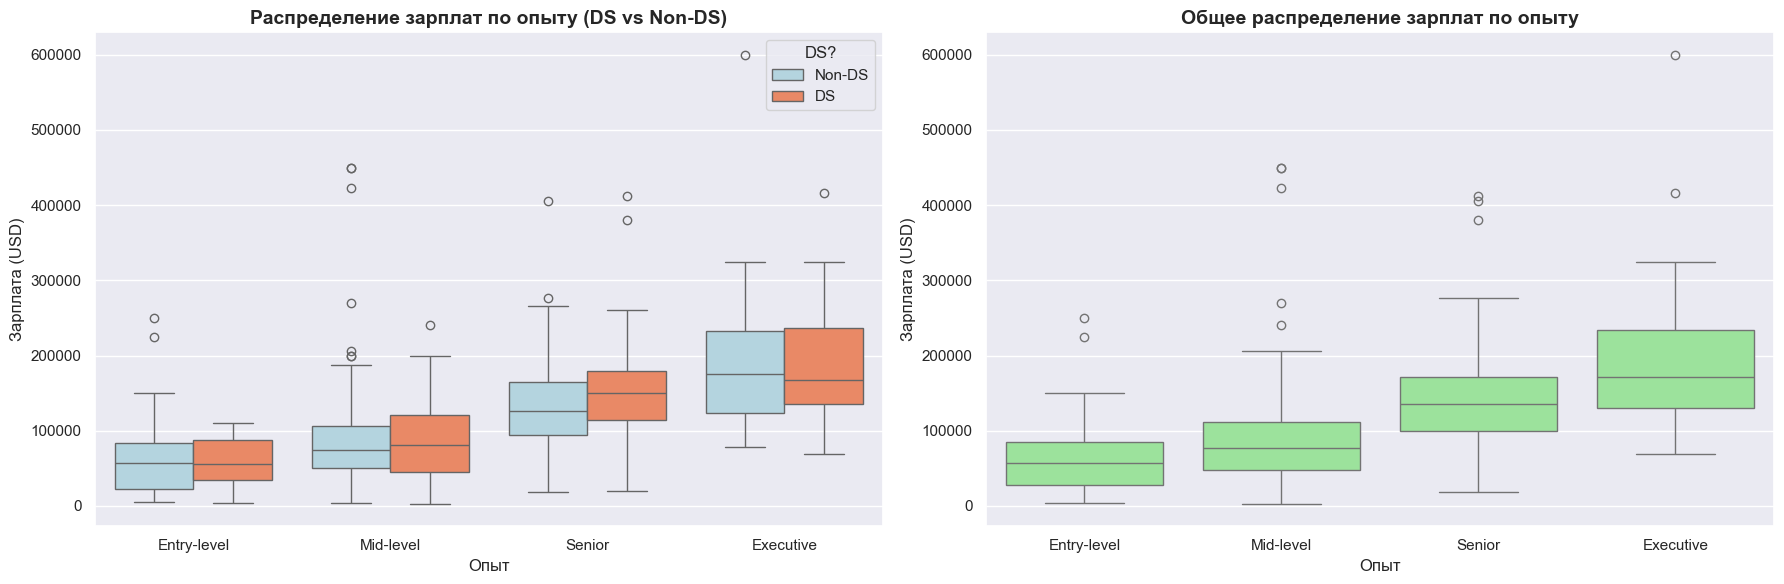

In [76]:
# Создаем subplot с двумя графиками
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# График с распределением DS vs Non-DS
sns.boxplot(x='experience_level', y='salary_in_usd', hue='is_ds', data=df_salaries, 
            order=['EN', 'MI', 'SE', 'EX'],
            palette={0: 'lightblue', 1: 'coral'}, ax=ax1)
ax1.set_title('Распределение зарплат по опыту (DS vs Non-DS)', fontsize=14, weight='bold')
ax1.set_xlabel('Опыт', fontsize=12)
ax1.set_ylabel('Зарплата (USD)', fontsize=12)
ax1.set_xticks(ticks=[0, 1, 2, 3])
ax1.set_xticklabels(['Entry-level', 'Mid-level', 'Senior', 'Executive'])
handles, _ = ax1.get_legend_handles_labels()
ax1.legend(handles, ['Non-DS', 'DS'], title='DS?')

# Все наблюдения без разделения
sns.boxplot(x='experience_level', y='salary_in_usd', data=df_salaries, 
            order=['EN', 'MI', 'SE', 'EX'],
            color='lightgreen', ax=ax2)
ax2.set_title('Общее распределение зарплат по опыту', fontsize=14, weight='bold')
ax2.set_xlabel('Опыт', fontsize=12)
ax2.set_ylabel('Зарплата (USD)', fontsize=12)
ax2.set_xticks(ticks=[0, 1, 2, 3])
ax2.set_xticklabels(['Entry-level', 'Mid-level', 'Senior', 'Executive'])

plt.tight_layout()
plt.show()

Выводы:
* С ростом квалификации растет и заработная плата для всех специальностей.
* На основе разбивки на DS и не DS специалистов видно, что заработные платы также растут с ростом опыта. Наиболее оплачиваемые - Executive.
* Для новичков (Entry) минимальная разница в зарплатах между DS и Non-DS позициями. 
* Небольшой разрыв происходит с уровня Mid, а на Senior максимальная разница ЗП - DS специалисты получают значительно больше.
* С ростом уровня специалиста увеличивается разброс ЗП, а также наибольшее количество выбросов для Mid и Senior.
* Для специалистов Non-DS рост ЗП более ровный, для DS основной скачок после перехода с Mid уровня.

### Распределение заработных плат в зависимости от года

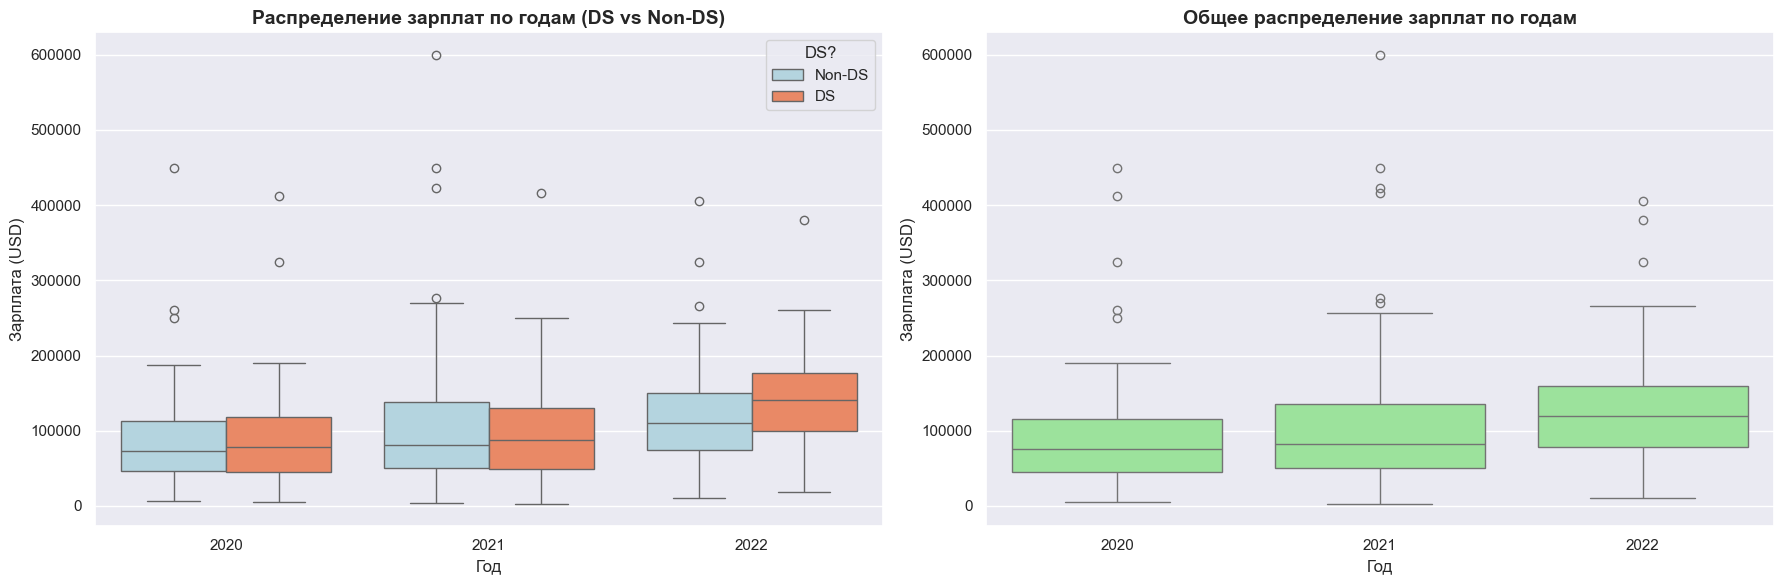

In [77]:
# Создаем subplot с двумя графиками
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# График с распределением DS vs Non-DS
sns.boxplot(x='work_year', y='salary_in_usd', hue='is_ds', data=df_salaries, 
            palette={0: 'lightblue', 1: 'coral'}, ax=ax1)
ax1.set_title('Распределение зарплат по годам (DS vs Non-DS)', fontsize=14, weight='bold')
ax1.set_xlabel('Год', fontsize=12)
ax1.set_ylabel('Зарплата (USD)', fontsize=12)
ax1.set_xticks(ticks=[0, 1, 2])
ax1.set_xticklabels(['2020', '2021', '2022'])  # Поправил года на более реалистичные
handles, _ = ax1.get_legend_handles_labels()
ax1.legend(handles, ['Non-DS', 'DS'], title='DS?')

# Все наблюдения без разделения
sns.boxplot(x='work_year', y='salary_in_usd', data=df_salaries, 
            color='lightgreen', ax=ax2)
ax2.set_title('Общее распределение зарплат по годам', fontsize=14, weight='bold')
ax2.set_xlabel('Год', fontsize=12)
ax2.set_ylabel('Зарплата (USD)', fontsize=12)
ax2.set_xticks(ticks=[0, 1, 2])
ax2.set_xticklabels(['2020', '2021', '2022'])

plt.tight_layout()
plt.show()

Выводы:
* Заметен рост медианных зарплат с 2020 по 2022 год. Особенно выраженный скачок произошел в 2022 году.
* В сравнении 2х групп: В 2020-2021 зарплаты DS близки к Non-DS, в 2022 происходит увеличение разрыва - DS позиции становятся более оплачиваемыми.
* Для Non-DS специалистов количество выбросов больше во все года.


### Распределение заработных плат в зависимости от специальности

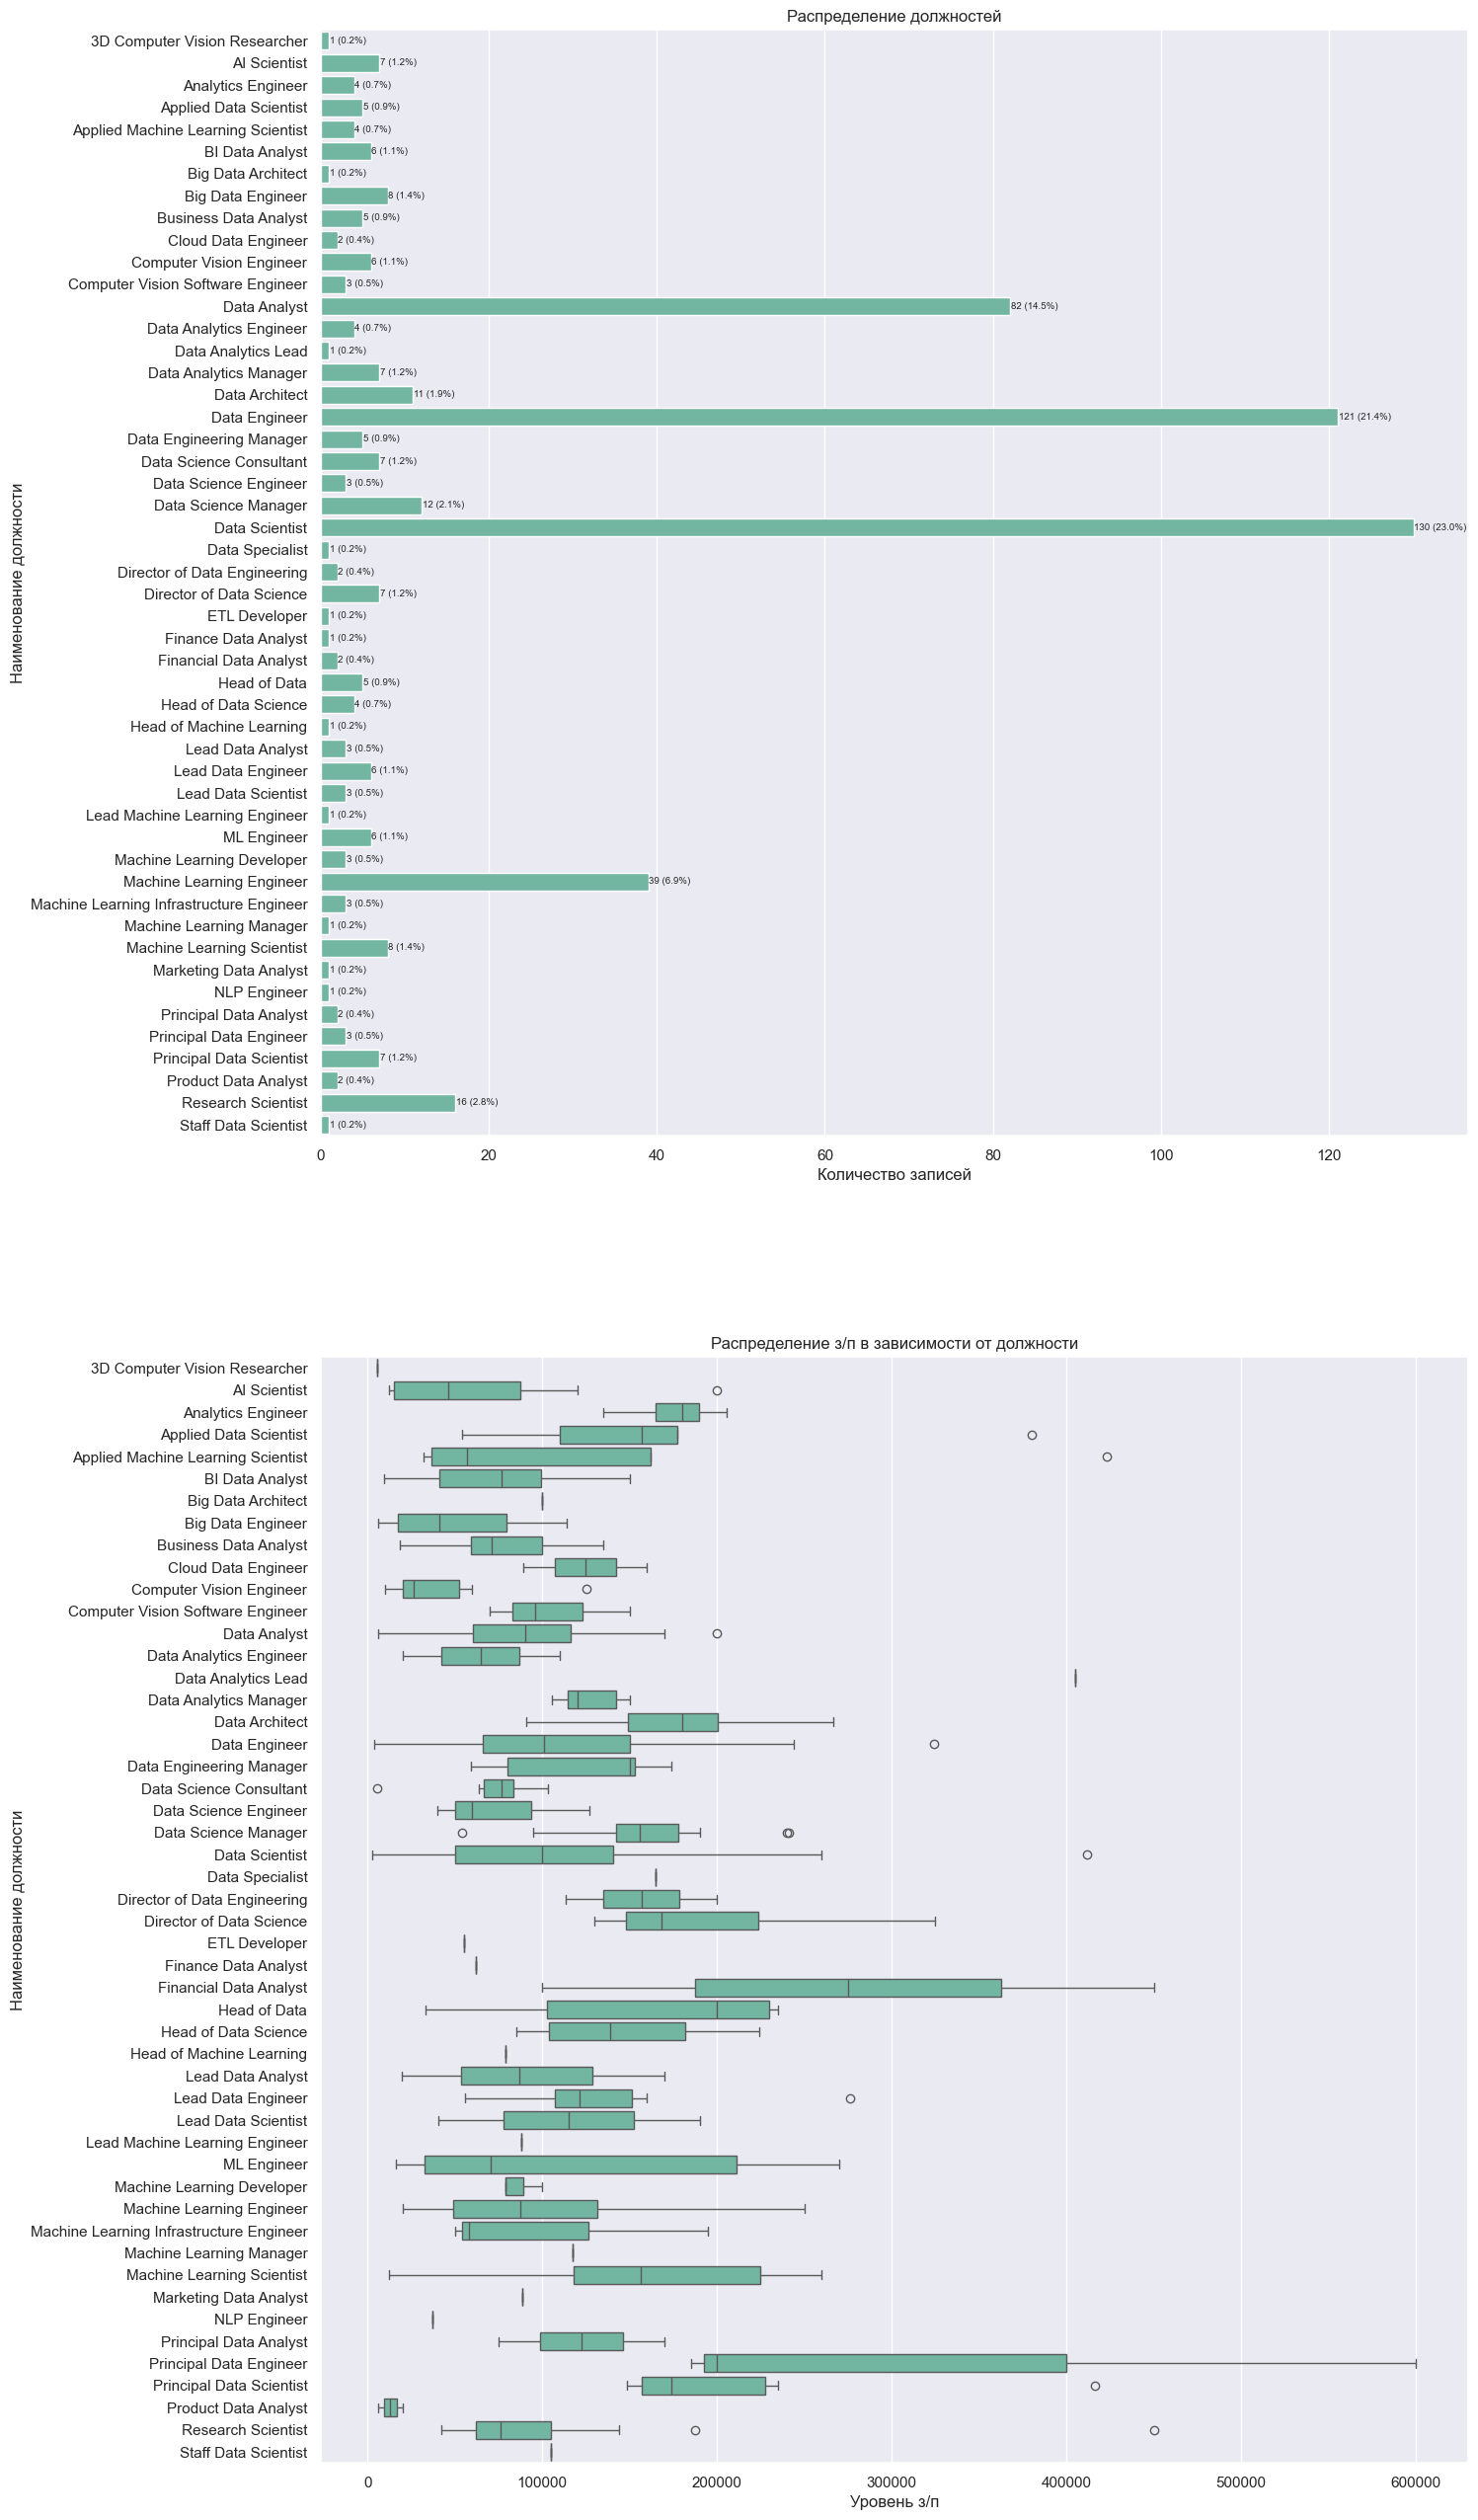

In [78]:
fig, axes = plt.subplots(2, 1, figsize=(15, 32))

axes[0] = sns.countplot(data=df_salaries, y=df_salaries['job_title'], ax=axes[0])
axes[0].set(xlabel='Количество записей', ylabel='Наименование должности')
axes[0].set_title('Распределение должностей')

total = len(df_salaries)
for p in axes[0].patches:
    width = p.get_width()
    percentage = f'{(100 * width / total):.1f}%'
    axes[0].text(width + 0.1, 
                p.get_y() + p.get_height()/2., 
                f'{int(width)} ({percentage})', 
                ha='left', 
                va='center',
                fontsize=7)

axes[1] = sns.boxplot(data=df_salaries, y=df_salaries['job_title'], x=df_salaries['salary_in_usd'], ax=axes[1])
axes[1].set(xlabel='Уровень з/п', ylabel='Наименование должности')
axes[1].set_title('Распределение з/п в зависимости от должности')

plt.show()

Выводы:
* Наибольшее значение зарпалаты (выброс) принадлежит профессии Principal Data Engineer, представленной в данных всего тремя специалистами.
* Далее по уровню зарплаты лидирует Financial Data Analyst с 2-мя представителями.
* Зарплатные рамки для Data Science и Data Engineer специалистов очень схожи.
* Наиболее популярные специальности в выборке по количеству участников: Data Scientist, Data Engineer и Data Analyst.

### Зависимость распределения заработных плат от объема работ, выполняемых удаленно

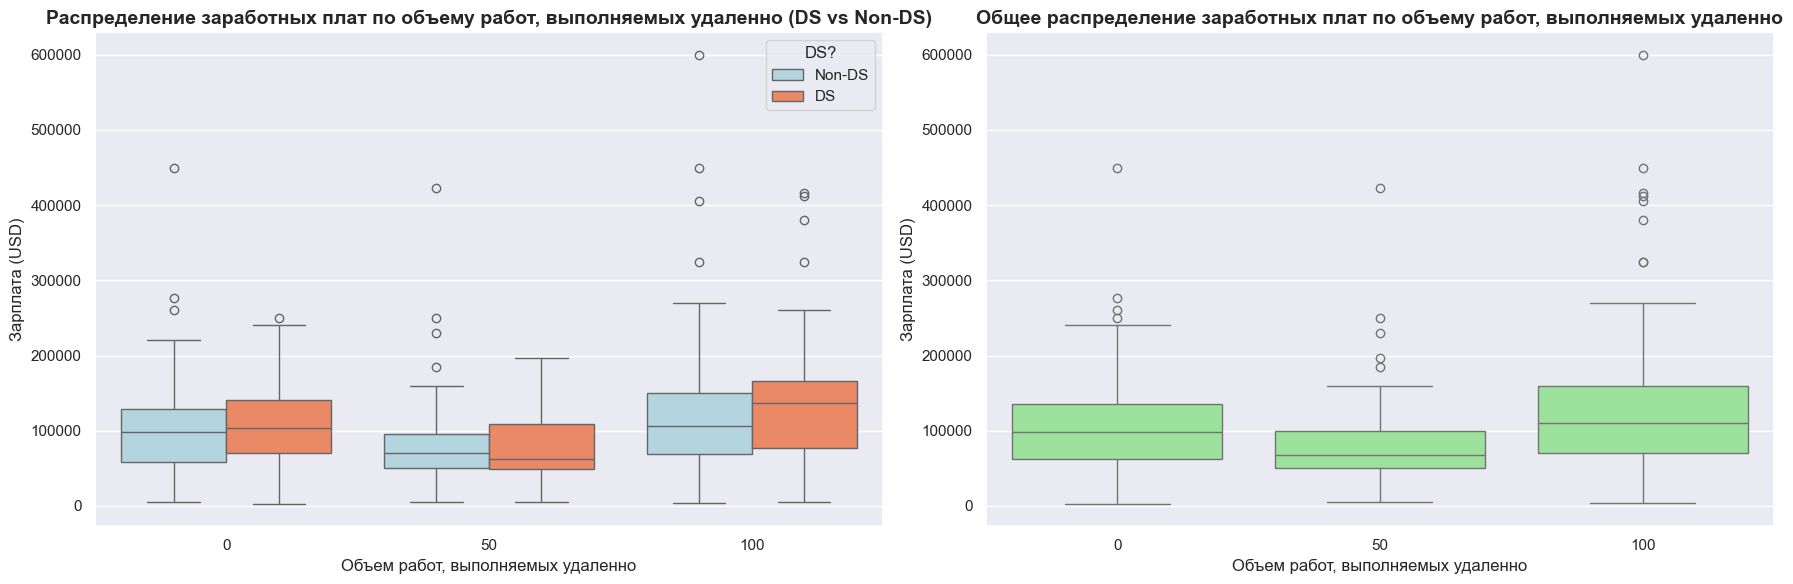

In [79]:
# Создаем subplot с двумя графиками
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# График с распределением DS vs Non-DS
sns.boxplot(x='remote_ratio', y='salary_in_usd', hue='is_ds', data=df_salaries, 
            palette={0: 'lightblue', 1: 'coral'}, ax=ax1)
ax1.set_title('Распределение заработных плат по объему работ, выполняемых удаленно (DS vs Non-DS)', fontsize=14, weight='bold')
ax1.set_xlabel('Объем работ, выполняемых удаленно', fontsize=12)
ax1.set_ylabel('Зарплата (USD)', fontsize=12)
ax1.set_xticks(ticks=[0, 1, 2])
ax1.set_xticklabels(['0', '50', '100']) 
handles, _ = ax1.get_legend_handles_labels()
ax1.legend(handles, ['Non-DS', 'DS'], title='DS?')

# Все наблюдения без разделения
sns.boxplot(x='remote_ratio', y='salary_in_usd', data=df_salaries, 
            color='lightgreen', ax=ax2)
ax2.set_title('Общее распределение заработных плат по объему работ, выполняемых удаленно', fontsize=14, weight='bold')
ax2.set_xlabel('Объем работ, выполняемых удаленно', fontsize=12)
ax2.set_ylabel('Зарплата (USD)', fontsize=12)
ax2.set_xticks(ticks=[0, 1, 2])
ax2.set_xticklabels(['0', '50', '100'])

plt.tight_layout()
plt.show()

Выводы:
* Как мы выяснили ранее, наибольшее количетсво специалистов предпочитает удаленный график, следующая группа - полный офис, гибрид - меньшинство. 
* По распределению зарплат для гибридного графика уровень ЗП самый низкий, наиболее оплачивается работа на удаленке, офис занимает 2е место.
* Если рассматривать разделение на DS non-DS, то видно, что закономерность сохраняется для обеих групп: наиболее выгодная - удаленка, наименее - гибрид.
* Различия в ЗП для офисных сотрудников менее заметны, чем для полных удаленщиков - большая разница между DS non-DS

### Зависимость распределения заработных плат от географической удаленности

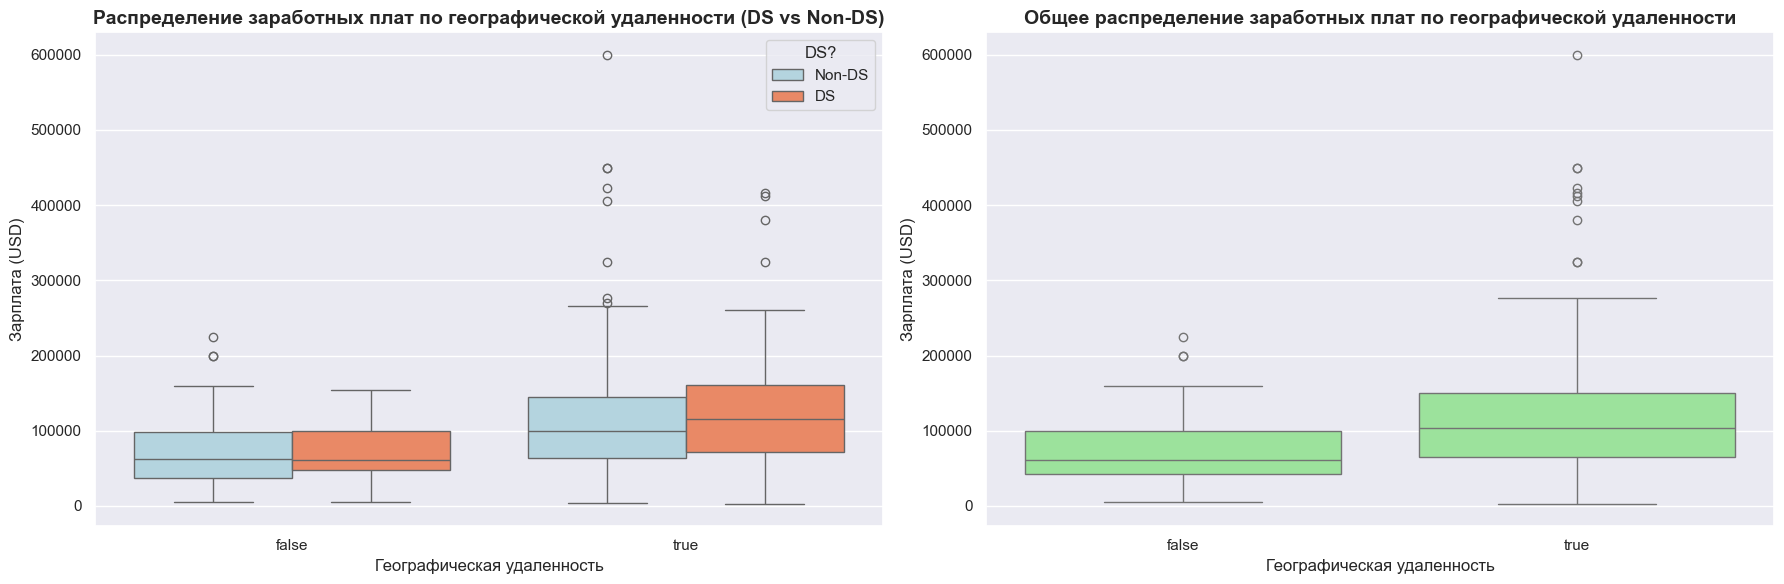

In [80]:
# Создаем subplot с двумя графиками
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# График с распределением DS vs Non-DS
sns.boxplot(x='geo_proximity', y='salary_in_usd', hue='is_ds', data=df_salaries, 
            palette={0: 'lightblue', 1: 'coral'}, ax=ax1)
ax1.set_title('Распределение заработных плат по географической удаленности (DS vs Non-DS)', fontsize=14, weight='bold')
ax1.set_xlabel('Географическая удаленность', fontsize=12)
ax1.set_ylabel('Зарплата (USD)', fontsize=12)
ax1.set_xticks(ticks=[0, 1])
ax1.set_xticklabels(['false', 'true'])  
handles, _ = ax1.get_legend_handles_labels()
ax1.legend(handles, ['Non-DS', 'DS'], title='DS?')

# Все наблюдения без разделения
sns.boxplot(x='geo_proximity', y='salary_in_usd', data=df_salaries, 
            color='lightgreen', ax=ax2)
ax2.set_title('Общее распределение заработных плат по географической удаленности', fontsize=14, weight='bold')
ax2.set_xlabel('Географическая удаленность', fontsize=12)
ax2.set_ylabel('Зарплата (USD)', fontsize=12)
ax2.set_xticks(ticks=[0, 1])
ax2.set_xticklabels(['false', 'true'])

plt.tight_layout()
plt.show()

C:\Users\nsemkina\AppData\Local\Temp\ipykernel_14312\3071388842.py:21: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



C:\Users\nsemkina\AppData\Local\Temp\ipykernel_14312\3071388842.py:49: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




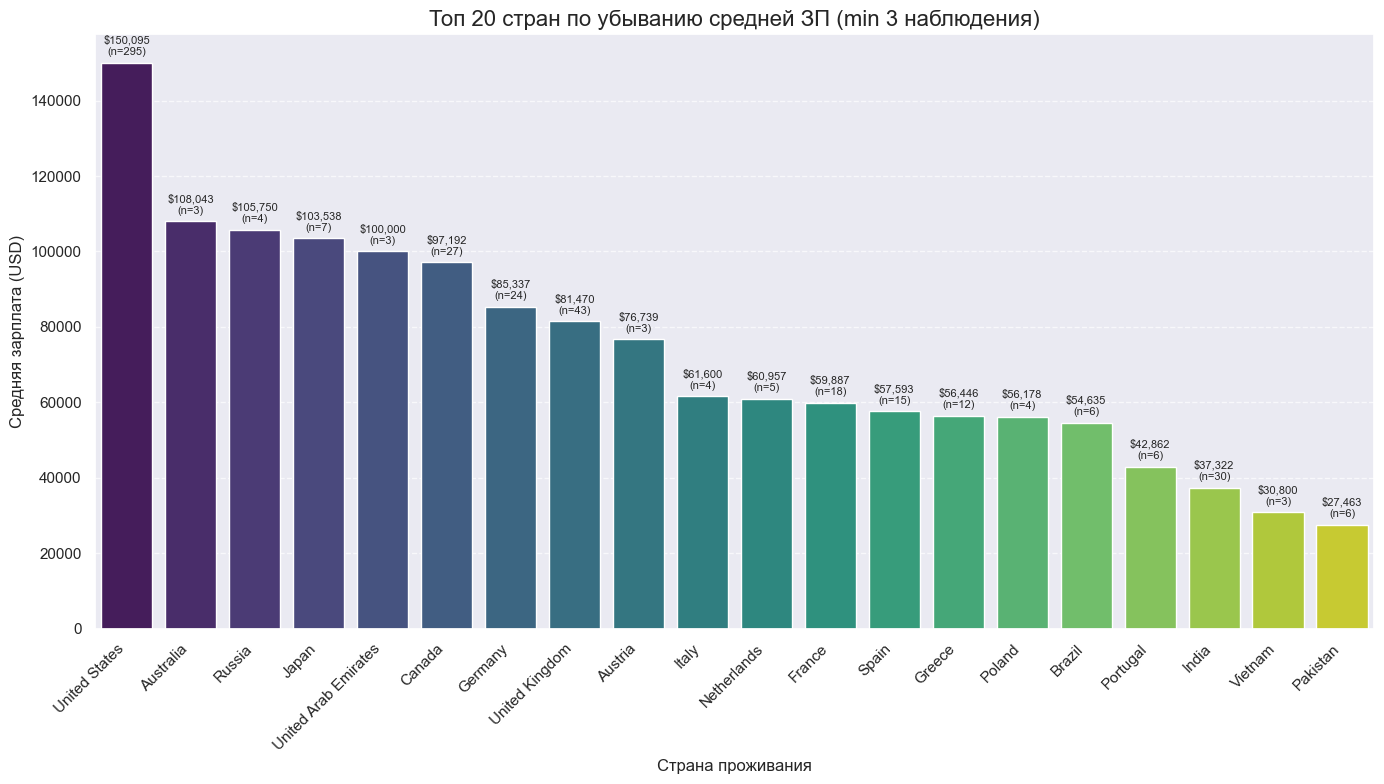

Всего стран в данных: 57
Стран с 3+ наблюдениями: 21
Отфильтровано стран: 36


In [81]:
df_salaries['adjusted_salary'] = df_salaries['salary_in_usd']

# Сделаем сопоставление страны по ISO-2

iso2_to_name = {
    'DE': 'Germany', 'JP': 'Japan', 'GB': 'United Kingdom', 'HN': 'Honduras', 'US': 'United States',
    'HU': 'Hungary', 'NZ': 'New Zealand', 'FR': 'France', 'IN': 'India', 'PK': 'Pakistan',
    'PL': 'Poland', 'PT': 'Portugal', 'CN': 'China', 'GR': 'Greece', 'AE': 'United Arab Emirates',
    'NL': 'Netherlands', 'MX': 'Mexico', 'CA': 'Canada', 'AT': 'Austria', 'NG': 'Nigeria',
    'PH': 'Philippines', 'ES': 'Spain', 'DK': 'Denmark', 'RU': 'Russia', 'IT': 'Italy',
    'HR': 'Croatia', 'BG': 'Bulgaria', 'SG': 'Singapore', 'BR': 'Brazil', 'IQ': 'Iraq',
    'VN': 'Vietnam', 'BE': 'Belgium', 'UA': 'Ukraine', 'MT': 'Malta', 'CL': 'Chile',
    'RO': 'Romania', 'IR': 'Iran', 'CO': 'Colombia', 'MD': 'Moldova', 'KE': 'Kenya',
    'SI': 'Slovenia', 'HK': 'Hong Kong', 'TR': 'Turkey', 'RS': 'Serbia', 'PR': 'Puerto Rico',
    'LU': 'Luxembourg', 'JE': 'Jersey', 'CZ': 'Czech Republic', 'AR': 'Argentina', 'DZ': 'Algeria',
    'TN': 'Tunisia', 'MY': 'Malaysia', 'EE': 'Estonia', 'AU': 'Australia', 'BO': 'Bolivia',
    'IE': 'Ireland', 'CH': 'Switzerland'
}

# Рассчитаем среднюю ЗП по стране проживания и сосчитаем кол-во наблюдений для страны
salary_stats = df_salaries.groupby('employee_residence')['adjusted_salary'].agg(['mean', 'count']).reset_index()
salary_stats.columns = ['employee_residence', 'adjusted_salary', 'observation_count']

# Создаем связку с названиями стран
salary_stats['country_name'] = salary_stats['employee_residence'].map(iso2_to_name)

# Убираем страны, где менее 3 наблюдений
avg_salary_by_residence = salary_stats[salary_stats['observation_count'] >= 3]

# Создаем карту
fig2 = px.choropleth(avg_salary_by_residence,
                     locations='country_name',
                     locationmode='country names',
                     color='adjusted_salary',
                     hover_name='country_name',
                     hover_data={'employee_residence': True, 'adjusted_salary': ':,.0f', 'observation_count': True},
                     color_continuous_scale=px.colors.sequential.Plasma,
                     title='Средняя ЗП по стране проживания (min 3 наблюдения)',
                     labels={'adjusted_salary': 'Средняя зарплата (USD)'},
                     projection='natural earth')

fig2.update_layout(width=1000, height=600)
fig2.show()

# Создаем гистограмму
top_countries = avg_salary_by_residence.sort_values('adjusted_salary', ascending=False).head(20)

plt.figure(figsize=(14, 8))
chart = sns.barplot(x='country_name', y='adjusted_salary', data=top_countries, 
                    palette='viridis', order=top_countries['country_name'])
plt.title('Топ 20 стран по убыванию средней ЗП (min 3 наблюдения)', fontsize=16)
plt.xlabel('Страна проживания', fontsize=12)
plt.ylabel('Средняя зарплата (USD)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

for i, bar in enumerate(chart.patches):
    chart.text(bar.get_x() + bar.get_width()/2., 
              bar.get_height() + 2000,
              f'${top_countries["adjusted_salary"].iloc[i]:,.0f}\n(n={top_countries["observation_count"].iloc[i]})', 
              ha='center', fontsize=8)

plt.tight_layout()
plt.show()

print(f"Всего стран в данных: {len(salary_stats)}")
print(f"Стран с 3+ наблюдениями: {len(avg_salary_by_residence)}")
print(f"Отфильтровано стран: {len(salary_stats) - len(avg_salary_by_residence)}")


C:\Users\nsemkina\AppData\Local\Temp\ipykernel_14312\3933161844.py:2: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



C:\Users\nsemkina\AppData\Local\Temp\ipykernel_14312\3933161844.py:30: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




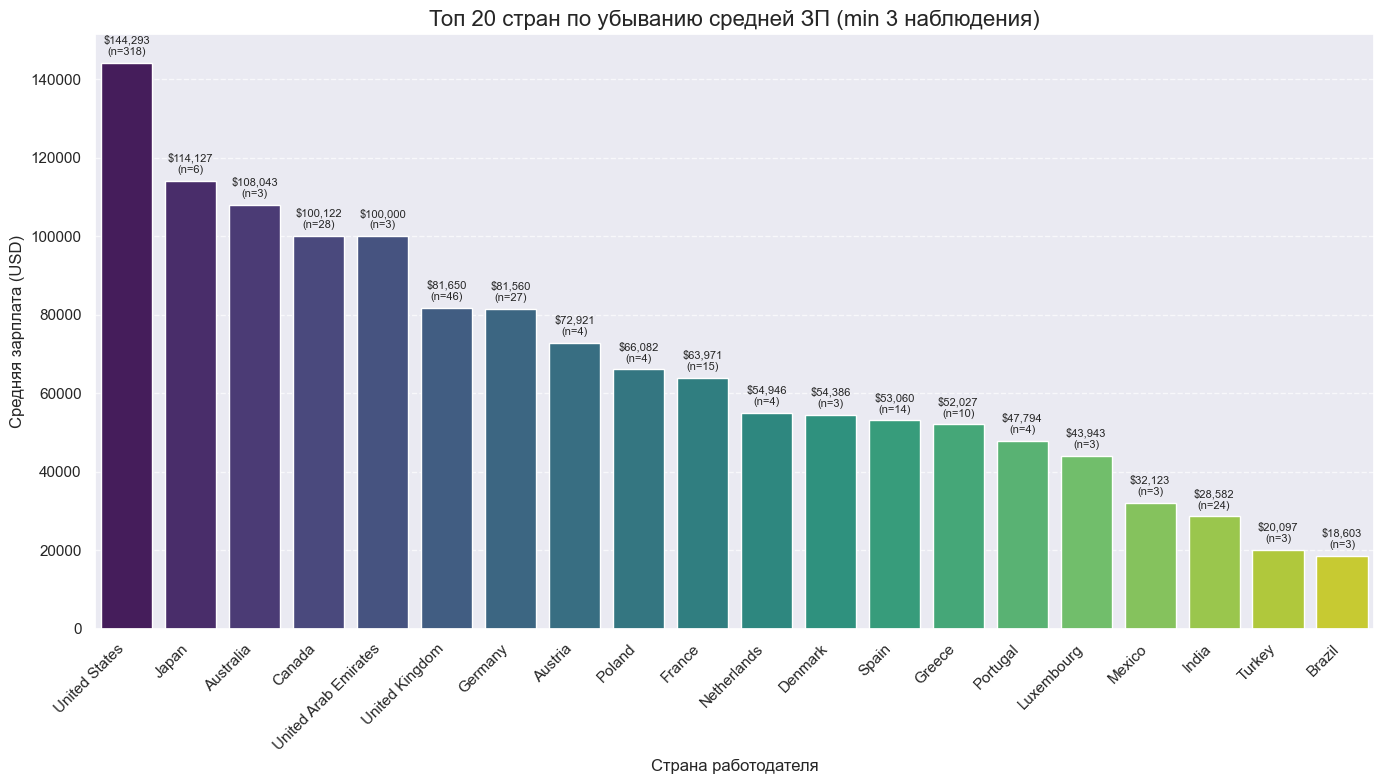

Всего стран в данных: 50
Стран с 3+ наблюдениями: 21
Отфильтровано стран: 29


In [82]:
# Рассчитаем среднюю ЗП по стране работодателя и сосчитаем кол-во наблюдений для страны
salary_stats = df_salaries.groupby('company_location')['adjusted_salary'].agg(['mean', 'count']).reset_index()
salary_stats.columns = ['company_location', 'adjusted_salary', 'observation_count']

# Создаем связку с названиями стран
salary_stats['country_name'] = salary_stats['company_location'].map(iso2_to_name)

# Убираем страны, где менее 3 наблюдений
avg_salary_by_residence = salary_stats[salary_stats['observation_count'] >= 3]

# Создаем карту
fig2 = px.choropleth(avg_salary_by_residence,
                     locations='country_name',
                     locationmode='country names',
                     color='adjusted_salary',
                     hover_name='country_name',
                     hover_data={'company_location': True, 'adjusted_salary': ':,.0f', 'observation_count': True},
                     color_continuous_scale=px.colors.sequential.Plasma,
                     title='Средняя ЗП по стране работодателя (min 3 наблюдения)',
                     labels={'adjusted_salary': 'Средняя зарплата (USD)'},
                     projection='natural earth')

fig2.update_layout(width=1000, height=600)
fig2.show()

# Создаем гистограмму
top_countries = avg_salary_by_residence.sort_values('adjusted_salary', ascending=False).head(20)

plt.figure(figsize=(14, 8))
chart = sns.barplot(x='country_name', y='adjusted_salary', data=top_countries, 
                    palette='viridis', order=top_countries['country_name'])
plt.title('Топ 20 стран по убыванию средней ЗП (min 3 наблюдения)', fontsize=16)
plt.xlabel('Страна работодателя', fontsize=12)
plt.ylabel('Средняя зарплата (USD)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

for i, bar in enumerate(chart.patches):
    chart.text(bar.get_x() + bar.get_width()/2., 
              bar.get_height() + 2000,
              f'${top_countries["adjusted_salary"].iloc[i]:,.0f}\n(n={top_countries["observation_count"].iloc[i]})', 
              ha='center', fontsize=8)

plt.tight_layout()
plt.show()

print(f"Всего стран в данных: {len(salary_stats)}")
print(f"Стран с 3+ наблюдениями: {len(avg_salary_by_residence)}")
print(f"Отфильтровано стран: {len(salary_stats) - len(avg_salary_by_residence)}")

Выводы:
* Так как наибольшее количетсво наблюдений и со стороны работника и со стороны работодателя из US, то сложно заявлять о каких-то статистически значимых результатах наблюдений.
* По первому графику видно, что ЗП выше для работников, выбирающих трудиться в стране работодателя, выполняется для всех специальностей. Но это возможно из-за преобладающего большинства наблюдений из US.
* Работники из стран US, Австралия, Россия и ОАЭ зарабатывают в среднем больше других (более 100,000 usd).
* Работодатели из стран US, Япония, Австралия, Канада, ОАЭ предлагают наиболее привлекательные ЗП (более 100,000 usd).
* Для некоторых стран работнику выгоднее выбирать страну работодателя не соответствующую стране пребывания, чтобы ЗП была выше.

### Зависимость распределения заработных плат от размера компании

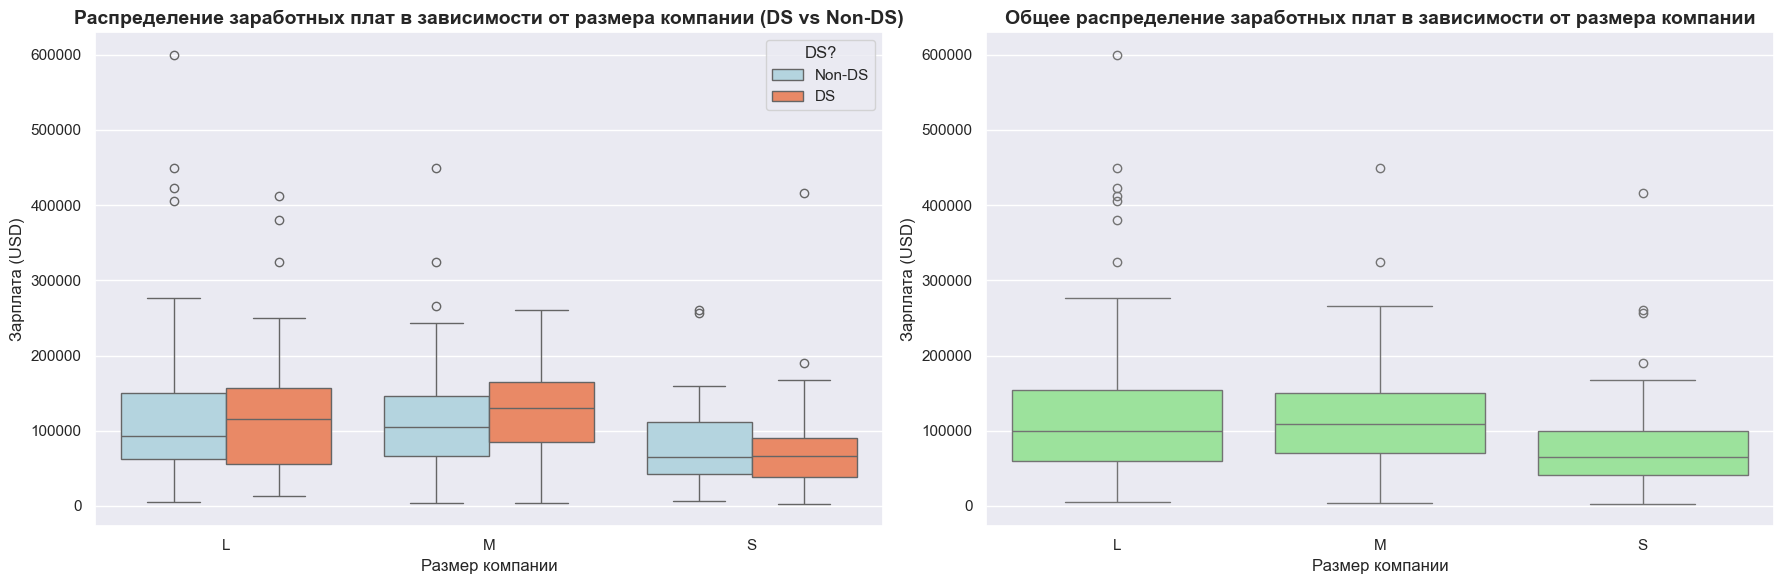

In [83]:
# Создаем subplot с двумя графиками
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# График с распределением DS vs Non-DS
sns.boxplot(x='company_size', y='salary_in_usd', hue='is_ds', data=df_salaries, 
            palette={0: 'lightblue', 1: 'coral'}, ax=ax1)
ax1.set_title('Распределение заработных плат в зависимости от размера компании (DS vs Non-DS)', fontsize=14, weight='bold')
ax1.set_xlabel('Размер компании', fontsize=12)
ax1.set_ylabel('Зарплата (USD)', fontsize=12)
ax1.set_xticks(ticks=[0, 1, 2])
ax1.set_xticklabels(['L', 'M', 'S'])  
handles, _ = ax1.get_legend_handles_labels()
ax1.legend(handles, ['Non-DS', 'DS'], title='DS?')

# Все наблюдения без разделения
sns.boxplot(x='company_size', y='salary_in_usd', data=df_salaries, 
            color='lightgreen', ax=ax2)
ax2.set_title('Общее распределение заработных плат в зависимости от размера компании', fontsize=14, weight='bold')
ax2.set_xlabel('Размер компании', fontsize=12)
ax2.set_ylabel('Зарплата (USD)', fontsize=12)
ax2.set_xticks(ticks=[0, 1, 2])
ax2.set_xticklabels(['L', 'M', 'S'])

plt.tight_layout()
plt.show()

Выводы:
* Для маленьких компаний характерна наименьшая зарплата, также количество наблюдений для таких компаний наименьшее.
* Для больших компаний характерно большее количество выбросов.
* DS специалисты наиболее ценны в среднего размера компаниях, больший разрыв между DS-nonDS
* В больших компаниях также имеется разница в оплате для DS-nonDS, но для nonDS разброс в ЗП больше в больших компаниях.

### Дополнительно рассмотрим сравнение специальностей Data Scientist и Data Engineer.

C:\Users\nsemkina\AppData\Local\Temp\ipykernel_14312\3733702372.py:14: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




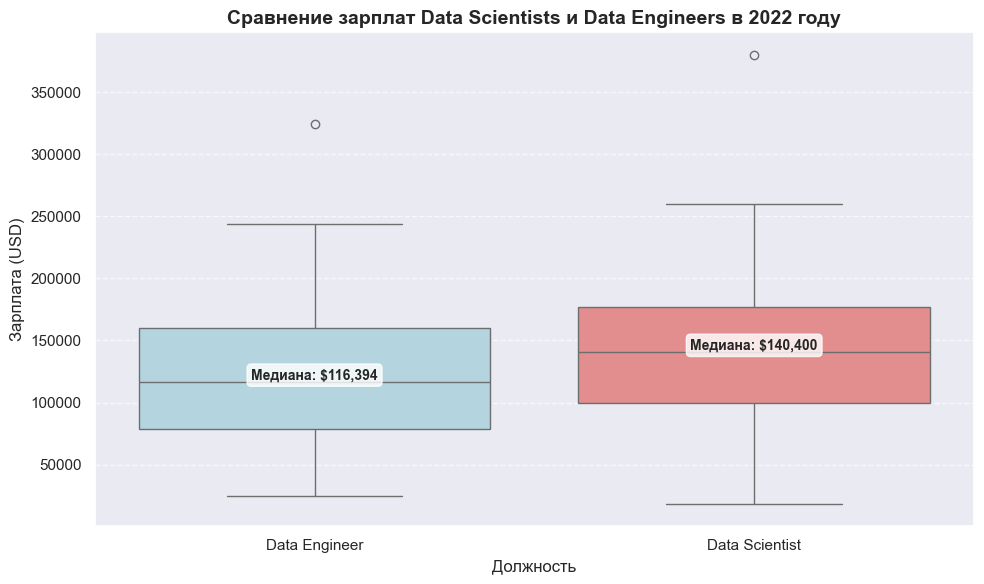

Статистика зарплат за 2022 год:
                count      mean    median      std    min     max
job_title                                                        
Data Engineer      80  124571.0  116394.0  57484.0  25000  324000
Data Scientist     78  139941.0  140400.0  61628.0  18442  380000


In [84]:
# Фильтруем данные за 2022 год для DS и DE специалистов
data_2022_ds_de = df_salaries[
    (df_salaries['work_year'] == 2022) & 
    (df_salaries['is_ds_or_de'] == 1)
].copy()

# Создаем столбец с названием должности
data_2022_ds_de['job_title'] = data_2022_ds_de['is_ds'].apply(lambda x: 'Data Scientist' if x == 1 else 'Data Engineer')

# Создаем график
plt.figure(figsize=(10, 6))

# Boxplot для сравнения зарплат DS и DE
sns.boxplot(data=data_2022_ds_de, x='job_title', y='salary_in_usd', 
           palette={'Data Scientist': 'lightcoral', 'Data Engineer': 'lightblue'})

plt.title('Сравнение зарплат Data Scientists и Data Engineers в 2022 году', fontsize=14, weight='bold')
plt.xlabel('Должность', fontsize=12)
plt.ylabel('Зарплата (USD)', fontsize=12)

# Добавляем медианы на график
medians = data_2022_ds_de.groupby('job_title')['salary_in_usd'].median()
for i, (title, median) in enumerate(medians.items()):
    plt.text(i, median, f'Медиана: ${median:,.0f}', 
             ha='center', va='bottom', fontsize=10, weight='bold',
             bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Выводим статистику
print("Статистика зарплат за 2022 год:")
print("=" * 50)
stats = data_2022_ds_de.groupby('job_title')['salary_in_usd'].agg(['count', 'mean', 'median', 'std', 'min', 'max']).round(0)
print(stats)

C:\Users\nsemkina\AppData\Local\Temp\ipykernel_14312\2221007280.py:26: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



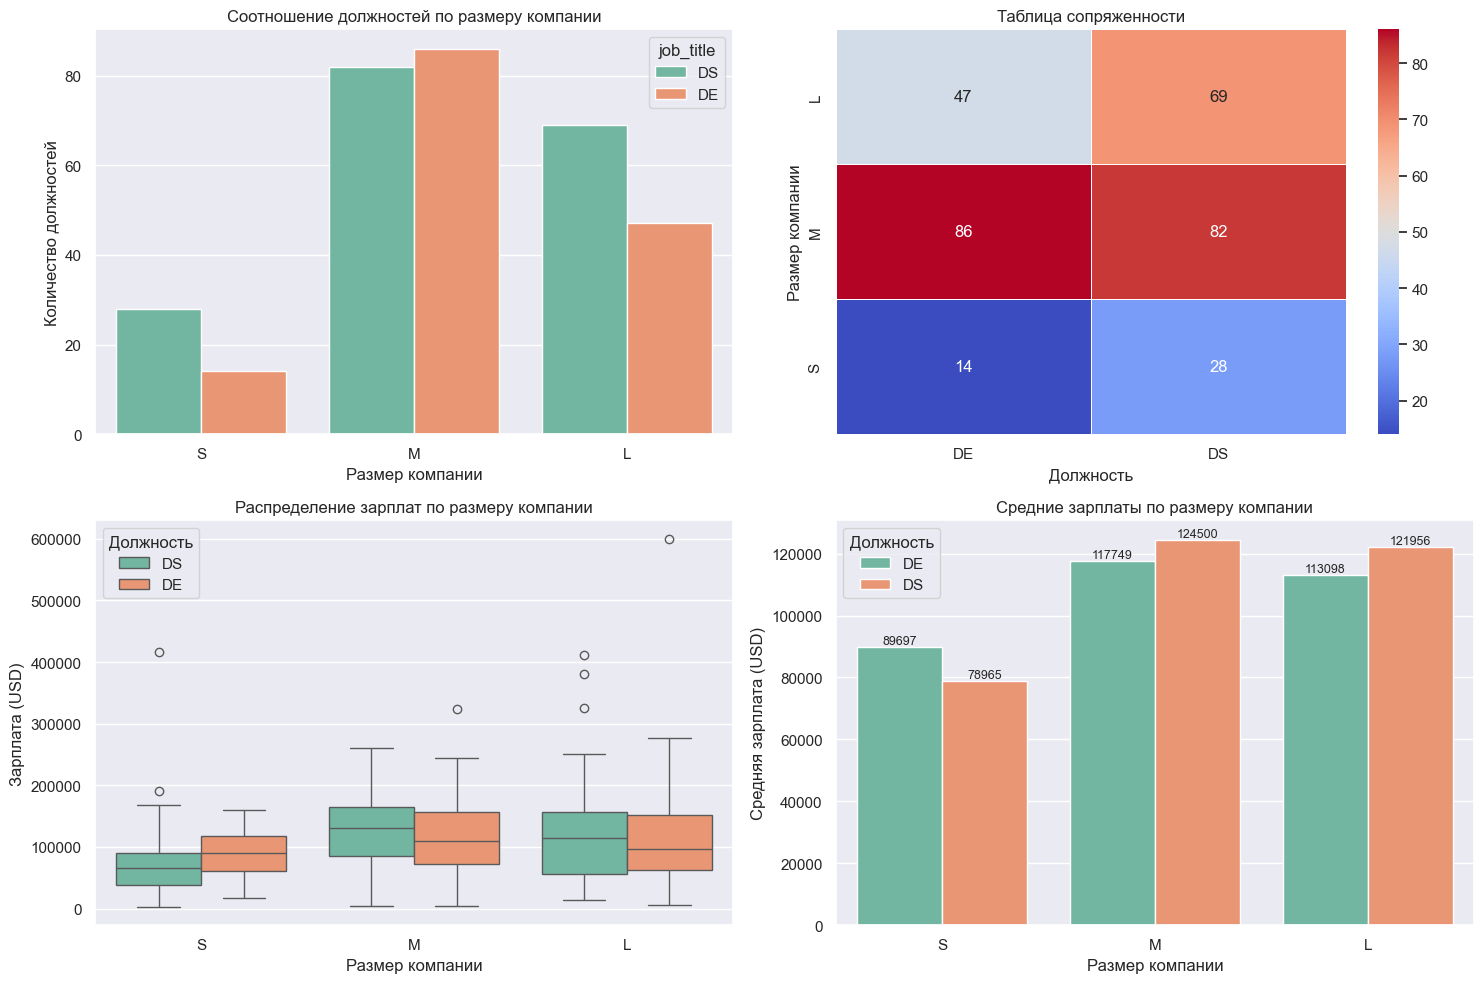

In [85]:
data_ds_de = df_salaries.copy()
data_ds_de = data_ds_de[data_ds_de['is_ds_or_de'] == 1]
data_ds_de['job_title'] = data_ds_de['is_ds'].apply(lambda x: 'DS' if x == 1 else 'DE')

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# График 1: Количество должностей по размеру компании
ax1 = sns.countplot(data=data_ds_de, x='company_size', hue='job_title', order=['S', 'M', 'L'], ax=axes[0,0])
axes[0,0].set(xlabel='Размер компании', ylabel='Количество должностей')
axes[0,0].set_title('Соотношение должностей по размеру компании')

# График 2: Таблица сопряженности
cross_tab = pd.crosstab(index=data_ds_de['company_size'], columns=data_ds_de['job_title'])
sns.heatmap(cross_tab, annot=True, linewidth=.5, fmt='.0f', cmap="coolwarm", ax=axes[0,1])
axes[0,1].set(xlabel='Должность', ylabel='Размер компании')
axes[0,1].set_title('Таблица сопряженности')

# График 3: Распределение зарплат по размеру компании и должности
sns.boxplot(data=data_ds_de, x='company_size', y='salary_in_usd', hue='job_title', 
           order=['S', 'M', 'L'], ax=axes[1,0])
axes[1,0].set(xlabel='Размер компании', ylabel='Зарплата (USD)')
axes[1,0].set_title('Распределение зарплат по размеру компании')
axes[1,0].legend(title='Должность')

# График 4: Средние зарплаты по размеру компании
avg_salary = data_ds_de.groupby(['company_size', 'job_title'])['salary_in_usd'].mean().reset_index()
sns.barplot(data=avg_salary, x='company_size', y='salary_in_usd', hue='job_title',
           order=['S', 'M', 'L'], ax=axes[1,1])
axes[1,1].set(xlabel='Размер компании', ylabel='Средняя зарплата (USD)')
axes[1,1].set_title('Средние зарплаты по размеру компании')
axes[1,1].legend(title='Должность')

for container in axes[1,1].containers:
    axes[1,1].bar_label(container, fmt='%.0f', fontsize=9)

plt.tight_layout()
plt.show()

Выводы:
* На 2022 год медианное значение ЗП выше для специалистов DS, в сравнении с DE.
* Для малых и больших компаний превалирует количество DS, для средних компаниий DE спциалистов больше.
* Средние зарплаты DS спецалистов выше в более крупных компаниях (M,L), в малых компаниях более ценны DE специалисты.

### Выводы по разделу

* Наблюдается рост зарпалат, не только для специалистов Data Science, но и для рынка в целом.
* На уровень заработной платы влияют все факторы, рассмотренные выше, но в рамках данной выборки наиболее значимыми считаю: experience_level, remote_ratio, company_size, также возможно влияние employee_residence
* В разрезе специалистов DS DE видим, что ЗП зависит от размера компании, более высокий уровень з/п в средних и больших компаниях. ЗП DE-специалистов выше только для малого размера компании.
* Связь между наличием должностей Data Scientist и Data Engineer и размером компании есть: только для среднего типа компании количество DE специалистов больше, чем DS.

##  Статистический анализ данных

In [86]:
# функция для принятия решения о нормальности
def decision_normality(p):
    print('p-value = {:.3f}'.format(p))
    if p <= alpha:
        print('p-значение меньше, чем заданный уровень значимости {:.2f}. Распределение отлично от нормального'.format(alpha))
    else:
        print('p-значение больше, чем заданный уровень значимости {:.2f}. Распределение является нормальным'.format(alpha))


# функция для принятия решения об отклонении нулевой гипотезы
def decision_hypothesis(p):
    print('p-value = {:.3f}'.format(p))
    if p <= alpha:
        print('p-значение меньше, чем заданный уровень значимости {:.2f}. Отвергаем нулевую гипотезу в пользу альтернативной.'.format(alpha))
    else:
        print('p-значение больше, чем заданный уровень значимости {:.2f}. У нас нет оснований отвергнуть нулевую гипотезу.'.format(alpha))

# Функция для проверки на равенство диспесий.
def decision_dispersion(p):
    print('p-value = {:.3f}'.format(p))
    if p <= alpha:
        print('Дисперсии не одинаковы, в stats.ttest_ind нужно использовать параметр equal_var=False.')
    else:
        print('Дисперсии одинаковы, в stats.ttest_ind нужно использовать параметр equal_var=True.')     

### Какие факторы влияют на зарплату специалиста Data Scientist.

Мы будем проверять значимость категориальных признаков, так как ранее уже заметили, что наибольшее количество наблюдений по географическим признакам принадледит USA, что не дает сделать выводы по влиянию данного признака.

Также не будем рассматривать год, его влияние будет проверяться отдельным тестом.

In [89]:
from scipy import stats

# Фильтруем данные только для Data Scientists
ds_data = df_salaries[df_salaries['is_ds'] == 1].copy()

print(f"Всего наблюдений Data Scientists: {len(ds_data)}")

# Выделяем категориальные признаки
categorical_features = ['experience_level', 'company_size', 'remote_ratio']

# Проводим статистические тесты для категориальных переменных
from scipy.stats import kruskal, f_oneway


for feature in categorical_features:
    groups = [group['salary_in_usd'].values for name, group in ds_data.groupby(feature) if len(group) > 1]
    
    if len(groups) >= 2:
        # Проверка нормальности
        normal_distributed = all(stats.shapiro(group)[1] > 0.05 for group in groups if len(group) > 3)
        
        if normal_distributed and len(groups) == len(ds_data[feature].unique()):
            # ANOVA для нормальных распределений
            f_stat, p_value = f_oneway(*groups)
            test_name = "ANOVA"
        else:
            # Крускал-Уоллис для ненормальных распределений
            f_stat, p_value = kruskal(*groups)
            test_name = "Kruskal-Wallis"
        
        print(f"{feature}: {test_name} p-value = {p_value:.4f} {'✅' if p_value < 0.05 else '❌'}")

Всего наблюдений Data Scientists: 179
experience_level: Kruskal-Wallis p-value = 0.0000 ✅
company_size: Kruskal-Wallis p-value = 0.0004 ✅
remote_ratio: Kruskal-Wallis p-value = 0.0003 ✅


C:\Users\nsemkina\AppData\Local\Temp\ipykernel_14312\3063003407.py:16: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



Тест Краскелла-Уоллиса показывает, что все 3 категориальных признака значимы и оказывают влияние на размер ЗП специалистов DS.

Проводим корреляционный анализ для категориальных переменных:

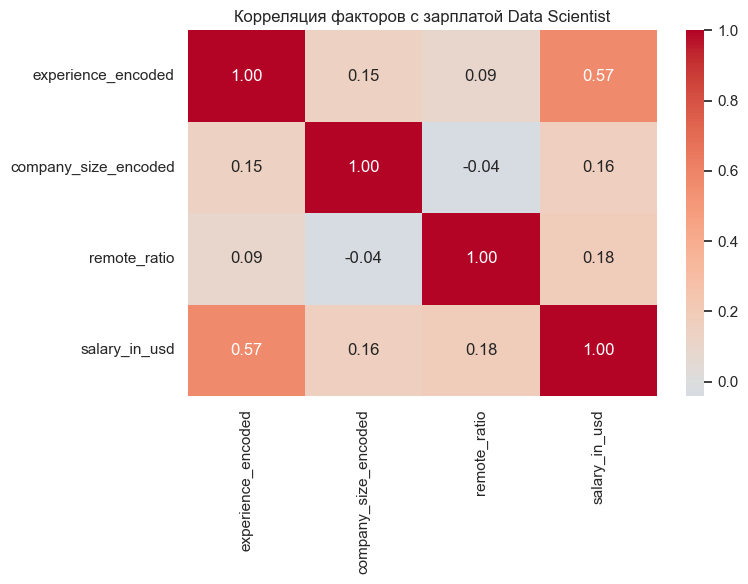

Корреляция с зарплатой:
experience_encoded: 0.575
remote_ratio: 0.177
company_size_encoded: 0.158


In [ ]:
# Создаем числовые представления категориальных переменных
ds_data_encoded = ds_data.copy()

# Кодируем категориальные переменные
experience_map = {'EN': 1, 'MI': 2, 'SE': 3, 'EX': 4}
company_size_map = {'S': 1, 'M': 2, 'L': 3}
employment_map = {'PT': 1, 'FT': 2, 'CT': 3, 'FL': 4}

ds_data_encoded['experience_encoded'] = ds_data_encoded['experience_level'].map(experience_map)
ds_data_encoded['company_size_encoded'] = ds_data_encoded['company_size'].map(company_size_map)

# Выбираем числовые переменные для корреляции
numeric_features = ['experience_encoded', 'company_size_encoded', 'remote_ratio']
correlation_matrix = ds_data_encoded[numeric_features + ['salary_in_usd']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Корреляция факторов с зарплатой Data Scientist')
plt.tight_layout()
plt.show()

print("Корреляция с зарплатой:")
salary_corr = correlation_matrix['salary_in_usd'].sort_values(ascending=False)
for feature, corr in salary_corr.items():
    if feature != 'salary_in_usd':
        print(f"{feature}: {corr:.3f}")

**Выводы:**

* Самое сильное влияние оказывает уровень опыта специалиста, чем более опытный специалист DS, тем большую зарпалту он может ожидать. (сильное влияние)
* Следующий по значимости фактор - удаленность работы. Для полных удаленщиков зарплата будет выше, чем для офисных работников. (умеренное влияние)
* Наименее значимый, но имеющий влияние фактор - размер компании. (умеренное влияние)

### Наблюдается ли ежегодный рост зарплат у специалистов Data Scientist?

**Сформулируем нулевую и альтернативные гипотезы**

*Нулевая гипотеза* ($H_0$): размер медианы зарплаты специалиста Data Science в 2020 ($μ_1$), 2021 ($μ_2$) и 2022 ($μ_3$) годах одинаковые:

$$ H_0 : μ_1 = μ_2 = μ_3 $$

*Альтернативная гипотеза* ($H_1$): размер медианы зарплаты специалиста Data Science в 2020 ($μ_1$), 2021 ($μ_2$) и 2022 ($μ_3$) годах отличаются:

$$ H_1 : μ_1 \neq μ_2 \neq μ_3 $$

**Проверка на нормальность**

С помощью теста Шапиро-Уилка проверим, распределён ли признак нормально.

*Нулевая гипотеза* ($H_0$): распределение данные является нормальным.

*Альтернативная гипотеза* ($H_1$): распределение данных отлично от нормального.

In [ ]:
from scipy import stats

salary_2020_ds = df_salaries[(df_salaries['work_year'] == 2020) & (df_salaries['is_ds']==1)]
salary_2021_ds = df_salaries[(df_salaries['work_year'] == 2021) & (df_salaries['is_ds']==1)]
salary_2022_ds = df_salaries[(df_salaries['work_year'] == 2022) & (df_salaries['is_ds']==1)]

# Добавьте отладочную информацию
print(f"Наблюдений в 2020: {len(salary_2020_ds)}")
print(f"Наблюдений в 2021: {len(salary_2021_ds)}")
print(f"Наблюдений в 2022: {len(salary_2022_ds)}")

print('\nДля 2020 (Data Scientists):')
if len(salary_2020_ds) > 3:
    result_2020 = stats.shapiro(salary_2020_ds['salary_in_usd'])
    print(f"Статистика: {result_2020[0]:.4f}, p-value: {result_2020[1]:.4f}")
    decision_normality(result_2020[1])
else:
    print("Недостаточно данных для теста")

print('\nДля 2021 (Data Scientists):')
if len(salary_2021_ds) > 3:
    result_2021 = stats.shapiro(salary_2021_ds['salary_in_usd'])
    print(f"Статистика: {result_2021[0]:.4f}, p-value: {result_2021[1]:.4f}")
    decision_normality(result_2021[1])
else:
    print("Недостаточно данных для теста")

print('\nДля 2022 (Data Scientists):')
if len(salary_2022_ds) > 3:
    result_2022 = stats.shapiro(salary_2022_ds['salary_in_usd'])
    print(f"Статистика: {result_2022[0]:.4f}, p-value: {result_2022[1]:.4f}")
    decision_normality(result_2022[1])
else:
    print("Недостаточно данных для теста")


Наблюдений в 2020: 28
Наблюдений в 2021: 73
Наблюдений в 2022: 78

Для 2020 (Data Scientists):
Статистика: 0.7740, p-value: 0.0000
p-value = 0.000
p-значение меньше, чем заданный уровень значимости 0.05. Распределение отлично от нормального

Для 2021 (Data Scientists):
Статистика: 0.8881, p-value: 0.0000
p-value = 0.000
p-значение меньше, чем заданный уровень значимости 0.05. Распределение отлично от нормального

Для 2022 (Data Scientists):
Статистика: 0.9665, p-value: 0.0378
p-value = 0.038
p-значение меньше, чем заданный уровень значимости 0.05. Распределение отлично от нормального


**Выберем подходящий статистический тест**

Для выбора нужного теста воспользуемся алгоритмом выбора теста. Для этого ответим на следующие вопросы:
* Какой тип у признака «Размер заработных плат»? — Количественный.
* Сколько сравниваемых групп? — Три.
* Группы зависимы? — Нет.
* Признак распределён по нормальному закону? — Все распределения отличны от нормального. 

Для проверки нашей гипотезы можно использовать критерий Краскела — Уоллиса.

**Проведём тест**

In [ ]:
# Проводим тест Крускала-Уоллиса
_, p = stats.kruskal(
    salary_2020_ds['salary_in_usd'], 
    salary_2021_ds['salary_in_usd'], 
    salary_2022_ds['salary_in_usd']
)
decision_hypothesis(p)

p-value = 0.000
p-значение меньше, чем заданный уровень значимости 0.05. Отвергаем нулевую гипотезу в пользу альтернативной.


In [ ]:
salary_2020_ds['salary_in_usd'].median() < salary_2021_ds['salary_in_usd'].median() < salary_2022_ds['salary_in_usd'].median()

np.True_

**Вывод**

Действительно наблюдается ежегодный рост зарплат у специалистов Data Science с 2020 по 2022. Медианные значения растут из года в год, статистическая значимость гипотезы подтверждена.

### Как соотносятся зарплаты специалистов Data Scientist в компаниях различных размеров?

**Сформулируем нулевую и альтернативные гипотезы**

*Нулевая гипотеза* ($H_0$): размер зарплаты специалистов Data Scientist в маленьких ($μ_1$), средних ($μ_2$) и больших ($μ_3$) компаниях одинаков:

$$ H_0 : μ_1 = μ_2 = μ_3 $$

*Альтернативная гипотеза* ($H_1$): размер зарплаты специалистов Data Scientist в маленьких ($μ_1$), средних ($μ_2$) и больших ($μ_3$) компаниях отличается:

$$ H_1 : μ_1 \neq μ_2 \neq μ_3 $$

**Проверка на нормальность**

С помощью теста Шапиро-Уилка проверим, распределён ли признак нормально.

In [ ]:
# Фильтрация по размеру компании И is_ds=1
size_S_ds = df_salaries[(df_salaries['company_size']=='S') & (df_salaries['is_ds']==1)]
size_M_ds = df_salaries[(df_salaries['company_size']=='M') & (df_salaries['is_ds']==1)]
size_L_ds = df_salaries[(df_salaries['company_size']=='L') & (df_salaries['is_ds']==1)]

print('\nДля компании S (Data Scientists):')
if len(size_S_ds) > 3:
    decision_normality(stats.shapiro(size_S_ds['salary_in_usd'])[1])
else:
    print("Недостаточно данных для теста")

print('\nДля компании M (Data Scientists):')
if len(size_M_ds) > 3:
    decision_normality(stats.shapiro(size_M_ds['salary_in_usd'])[1])
else:
    print("Недостаточно данных для теста")

print('\nДля компании L (Data Scientists):')
if len(size_L_ds) > 3:
    decision_normality(stats.shapiro(size_L_ds['salary_in_usd'])[1])
else:
    print("Недостаточно данных для теста")


Для компании S (Data Scientists):
p-value = 0.000
p-значение меньше, чем заданный уровень значимости 0.05. Распределение отлично от нормального

Для компании M (Data Scientists):
p-value = 0.785
p-значение больше, чем заданный уровень значимости 0.05. Распределение является нормальным

Для компании L (Data Scientists):
p-value = 0.000
p-значение меньше, чем заданный уровень значимости 0.05. Распределение отлично от нормального


**Выберем подходящий статистический тест**

Для выбора нужного теста воспользуемся алгоритмом выбора теста. Для этого ответим на следующие вопросы:
* Какой тип у признака «зарплата»? — Количественный.
* Сколько сравниваемых групп? — Три.
* Группы зависимы? — Нет.
* Признак распределён по нормальному закону? — Нет. 

Для проверки нашей гипотезы можно использовать критерий Краскела — Уоллиса.

**Проведём тест**

In [ ]:
_, p = stats.kruskal(size_S_ds['salary_in_usd'], size_M_ds['salary_in_usd'], size_L_ds['salary_in_usd'])
decision_hypothesis(p)

p-value = 0.000
p-значение меньше, чем заданный уровень значимости 0.05. Отвергаем нулевую гипотезу в пользу альтернативной.


**Вывод**

Статистически подтверждено, что размер заработных плат DS-специалистов различается в зависимости от размера компании работодателя.

### Как соотносятся зарплаты Data Scientist и Data Engineer в 2022 году?

**Сформулируем нулевую и альтернативные гипотезы**

*Нулевая гипотеза* ($H_0$): Медианные зарплаты Data Scientists ($μ_1$) и Data Engineers ($μ_2$) в 2022 году статистически не различаются:

$$ H_0 : μ_1 = μ_2 $$

*Альтернативная гипотеза* ($H_1$): Медианные зарплаты Data Scientists ($μ_1$) и Data Engineers ($μ_2$) в 2022 году статистически значимо различаются:

$$ H_1 : μ_1 \neq μ_2 $$

In [ ]:
# Разделяем данные
ds_salaries = data_2022_ds_de[data_2022_ds_de['job_title'] == 'Data Scientist']['salary_in_usd']
de_salaries = data_2022_ds_de[data_2022_ds_de['job_title'] == 'Data Engineer']['salary_in_usd']

# Проверка нормальности распределения
ds_normality = stats.shapiro(ds_salaries)
de_normality = stats.shapiro(de_salaries)

print(f"Data Scientists: p-value = {ds_normality[1]:.4f}")
decision_normality(ds_normality[1])
print(f"Data Engineers: p-value = {de_normality[1]:.4f}")
decision_normality(de_normality[1])

Data Scientists: p-value = 0.0378
p-value = 0.038
p-значение меньше, чем заданный уровень значимости 0.05. Распределение отлично от нормального
Data Engineers: p-value = 0.0068
p-value = 0.007
p-значение меньше, чем заданный уровень значимости 0.05. Распределение отлично от нормального


**Выберем подходящий статистический тест**

Для выбора нужного теста воспользуемся алгоритмом выбора теста. Для этого ответим на следующие вопросы:
* Какой тип у признака «Размер зарплаты»? — Количественный.
* Сколько сравниваемых групп? — Две.
* Группы зависимы? — Нет.
* Признак распределён по нормальному закону? — Нет.

Для проверки нашей гипотезы можно использовать U-критерий Манна — Уитни.

**Проведём тест**

In [ ]:
u_stat, p_value  = stats.mannwhitneyu(ds_salaries, de_salaries, alternative='two-sided')
print(f"U-статистика = {u_stat:.4f}, p-value = {p_value:.4f}")
decision_hypothesis(p_value)

U-статистика = 3643.0000, p-value = 0.0692
p-value = 0.069
p-значение больше, чем заданный уровень значимости 0.05. У нас нет оснований отвергнуть нулевую гипотезу.


**Вывод**

Зарплаты Data Scientists и Data Engineers значимо не различаются по данным на 2022 год.

### Есть ли связь между наличием должностей Data Scientist и Data Engineer и размером компании?

**Сформулируем нулевую и альтернативные гипотезы**

*Нулевая гипотеза* ($H_0$): Признаки "Размер компании" и "Должность" независимы.

*Альтернативная гипотеза* ($H_1$): Признаки "Размер компании" и "Должность" взаимосвязаны.

**Выберем подходящий статистический тест**

Для выбора нужного теста воспользуемся алгоритмом выбора теста. Для этого ответим на следующие вопросы:
* Какой тип у признака "Размер компании"? — Категориальный.
* Сколько сравниваемых групп? — Две.
* Проверяется независимость групп? — Да.

Для проверки нашей гипотезы можно использовать критерий ${\chi}^2$ (хи-квадрат).

**Проведём тест**

In [ ]:
# составляем таблицу сопряжённости
cross_table = pd.crosstab(df_salaries['is_ds_or_de'], df_salaries['company_size'])

data_ds_de = df_salaries[(df_salaries['job_title'] == 'Data Scientist') | (df_salaries['job_title'] == 'Data Engineer')]
cross_table = pd.crosstab(data_ds_de['job_title'], data_ds_de['company_size'])

cross_table

company_size,L,M,S
job_title,,,
Data Engineer,34,81,6
Data Scientist,43,66,21


In [ ]:
# проводим тест
_, p, _, _ = stats.chi2_contingency(cross_table)
decision_hypothesis(p)

p-value = 0.005
p-значение меньше, чем заданный уровень значимости 0.05. Отвергаем нулевую гипотезу в пользу альтернативной.


**Вывод**

Существует статистически значимая взаимосвязь между наличием должностей DS DE в компании и размером компании.

### Размеры заработных плат удаленщиков выше, чем у офисных работников?

**Сформулируем нулевую и альтернативные гипотезы**

*Нулевая гипотеза* ($H_0$): заработная плата удаленщика ($μ_1$) статистически меньше либо равна размеру ЗП офисного работника ($μ_2$).

$$ H_0 : μ_1 <= μ_2$$

*Альтернативная гипотеза* ($H_1$): заработная плата удаленщика ($μ_1$) статистически больше, чем размер ЗП офисного работника ($μ_2$).

$$ H_1 : μ_1 > μ_2$$

**Проверка на нормальность**

С помощью теста Шапиро-Уилка проверим, распределён ли признак нормально.

In [ ]:
# значения страховых выплат
charges_remote = df_salaries.loc[df_salaries['remote_ratio'] == 100, 'salary_in_usd']
charges_offline = df_salaries.loc[df_salaries['remote_ratio'] == 0, 'salary_in_usd']

# проводим тест Шапиро-Уилка
print('Для удаленщика:')
result = stats.shapiro(charges_remote)
decision_normality(result[1])

print('Для офиса:')
result = stats.shapiro(charges_offline)
decision_normality(result[1])

Для удаленщика:
p-value = 0.000
p-значение меньше, чем заданный уровень значимости 0.05. Распределение отлично от нормального
Для офиса:
p-value = 0.000
p-значение меньше, чем заданный уровень значимости 0.05. Распределение отлично от нормального


**Выберем подходящий статистический тест**

Для выбора нужного теста воспользуемся алгоритмом выбора теста. Для этого ответим на следующие вопросы:
* Какой тип у признака «Размер зарплаты»? — Количественный.
* Сколько сравниваемых групп? — Две.
* Группы зависимы? — Нет.
* Признак распределён по нормальному закону? — Нет.

Чтобы проверить нашу гипотезу, можно использовать U-критерий Манна — Уитни для сравнения распределений на основе рангов.

**Проведём тест**

In [ ]:
# проводим тест
_, p = stats.mannwhitneyu(charges_remote, charges_offline, alternative='greater')
decision_hypothesis(p)

p-value = 0.018
p-значение меньше, чем заданный уровень значимости 0.05. Отвергаем нулевую гипотезу в пользу альтернативной.


**Вывод**

Статистически подтверждаем, что без разделения на специальность, зарплата удаленщиков больше, чем у офисного работника.

### Есть ли значимая разница в ЗП для должностей Data Scientist и Data Engineer с опытом работы Executive

**Сформулируем нулевую и альтернативные гипотезы**

*Нулевая гипотеза* ($H_0$): Медианные зарплаты Executive Data Scientists ($μ_1$) и Data Engineers ($μ_2$) не различаются:

$$ H_0 : μ_1 = μ_2 $$

*Альтернативная гипотеза* ($H_1$): Медианные зарплаты Executive Data Scientists ($μ_1$) и Data Engineers ($μ_2$) не различаются:

$$ H_1 : μ_1 \neq μ_2 $$

In [ ]:
executive_ds_de = df_salaries[
    (df_salaries['experience_level'] == 'EX') & 
    (df_salaries['is_ds_or_de'] == 1)
].copy()

# Создаем столбец с названием должности
executive_ds_de['job_title'] = executive_ds_de['is_ds'].apply(
    lambda x: 'Data Scientist' if x == 1 else 'Data Engineer')
ds_salaries = executive_ds_de[executive_ds_de['job_title'] == 'Data Scientist']['salary_in_usd']
de_salaries = executive_ds_de[executive_ds_de['job_title'] == 'Data Engineer']['salary_in_usd']

C:\Users\nsemkina\AppData\Local\Temp\ipykernel_14312\3495559286.py:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




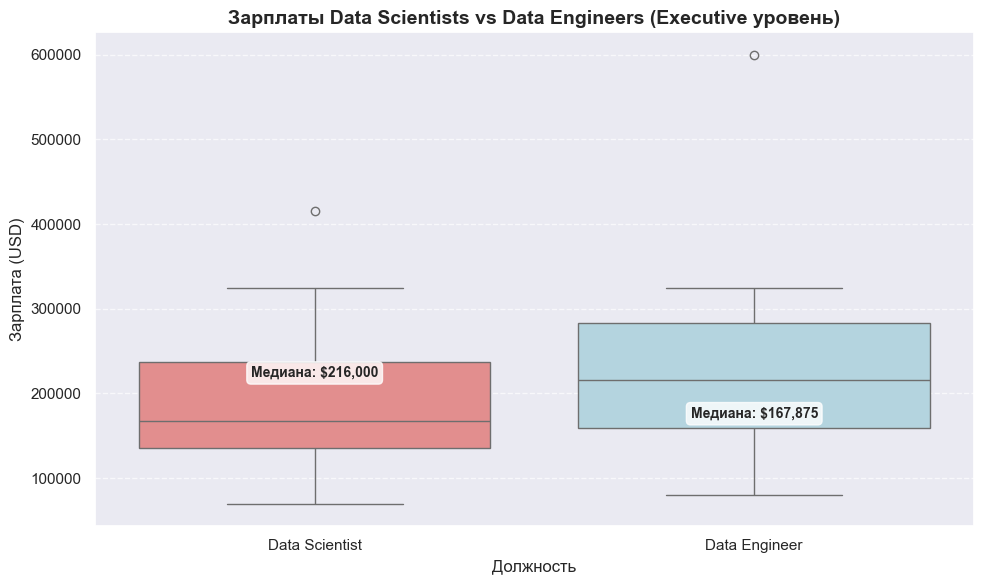

In [ ]:
# Визуализация
plt.figure(figsize=(10, 6))
sns.boxplot(data=executive_ds_de, x='job_title', y='salary_in_usd',
            palette={'Data Scientist': 'lightcoral', 'Data Engineer': 'lightblue'})
plt.title('Зарплаты Data Scientists vs Data Engineers (Executive уровень)', fontsize=14, weight='bold')
plt.xlabel('Должность', fontsize=12)
plt.ylabel('Зарплата (USD)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
    
# Добавляем медианы на график
medians = executive_ds_de.groupby('job_title')['salary_in_usd'].median()
for i, (title, median) in enumerate(medians.items()):
    plt.text(i, median, f'Медиана: ${median:,.0f}', 
             ha='center', va='bottom', fontsize=10, weight='bold',
             bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
    
plt.tight_layout()
plt.show()

**Проверка на нормальность**

С помощью теста Шапиро-Уилка проверим, распределён ли признак нормально.

In [ ]:
# Проверка нормальности
ds_normality = stats.shapiro(ds_salaries)
de_normality = stats.shapiro(de_salaries)
        
print(f"Data Scientists: p-value = {ds_normality[1]:.4f}")
decision_normality(ds_normality[1])
print(f"Data Engineers: p-value = {de_normality[1]:.4f}")
decision_normality(de_normality[1])

Data Scientists: p-value = 0.4181
p-value = 0.418
p-значение больше, чем заданный уровень значимости 0.05. Распределение является нормальным
Data Engineers: p-value = 0.1698
p-value = 0.170
p-значение больше, чем заданный уровень значимости 0.05. Распределение является нормальным


**Выберем подходящий статистический тест**

Для выбора нужного теста воспользуемся алгоритмом выбора теста. Для этого ответим на следующие вопросы:
* Какой тип у признака «Размер зарплаты»? — Количественный.
* Сколько сравниваемых групп? — Две.
* Группы зависимы? — Нет.
* Признак распределён по нормальному закону? — Да.

Для проверки нашей гипотезы можно использовать Двухвыборочный t-критерий.

**Проведём тест**

In [ ]:
test_stat, p_value = stats.ttest_ind(ds_salaries, de_salaries)
decision_hypothesis(p_value)

p-value = 0.383
p-значение больше, чем заданный уровень значимости 0.05. У нас нет оснований отвергнуть нулевую гипотезу.


**Вывод**

Зарплаты Data Scientists и Data Engineers на Executive уровне значимо не различаются.


## Итоговые результаты исследования

*   Наблюдается ежегодный рост зарпалт у специалистов Data Science в период с 2020 по 2022 год.
*   На 2022 год зарплаты DS и DE специалистов значимо не отличаются.
*   Размер заработных плат DS-специалистов различается в зависимости от размера компании работодателя.
*   Существует взаимосвязь между размером компании и должностями Data Scientist и Data Engineer.
*   Для всей выборки верно утверждение, что удаленщики получают больше офисных сотрудников.
*   На уровне Executive DS и DE специалисты зарплата значимо не различается.
*   На ЗП специалистов DS влияют более всего уровень квалификации, умеренное влияние оказывают размер компании и количество работы, выполняемой удаленно.